<a href="https://www.kaggle.com/code/hamidchaouchi/zeta-mirror-8-zm8-resonance?scriptVersionId=315002131" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-result.json
/kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-info.json


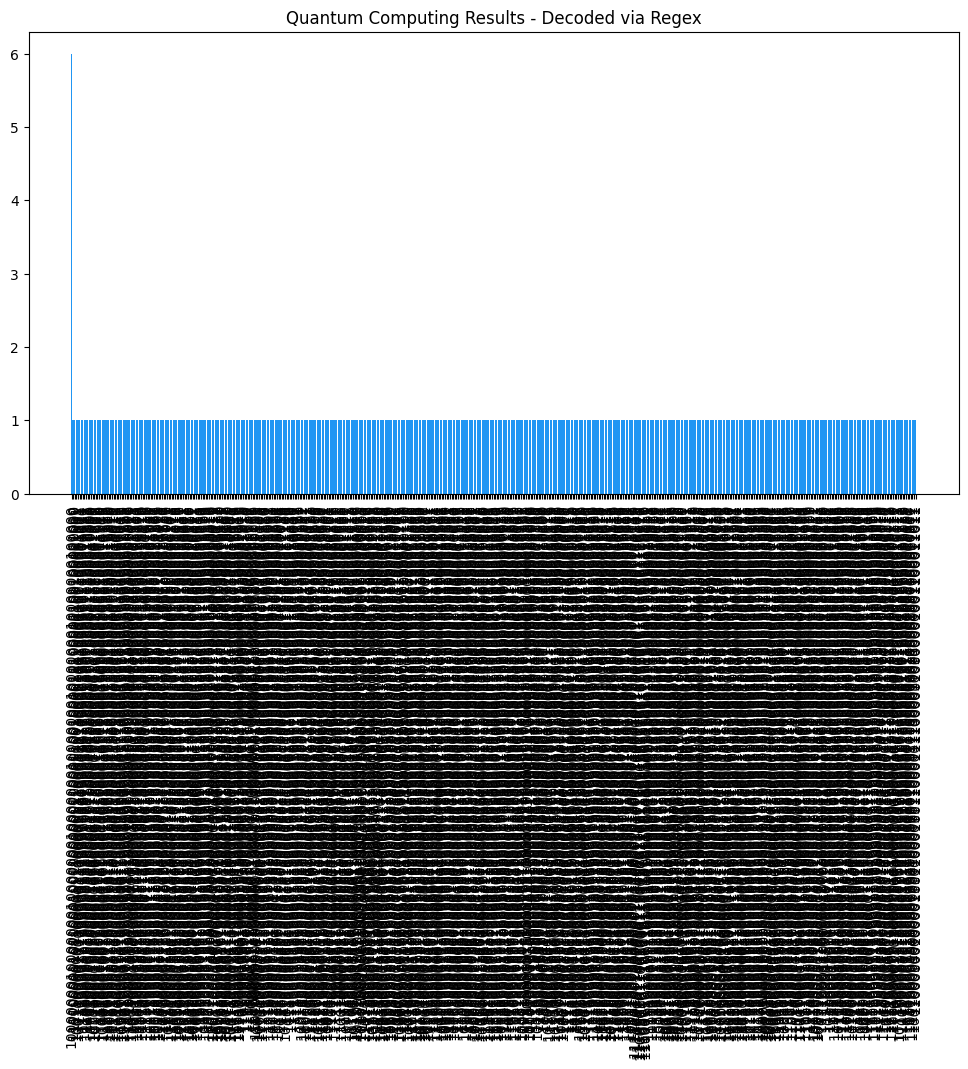

تم بنجاح! عدد النتائج المستخرجة: 523


,State,Frequency,Bitstring
9,2314885530818453536,6,1000000010000000100000001000000010000000100000...
343,1736437827740764938,1,1100000011001000100010000000100011001000010100...
344,1011640866249251088,1,1110000010100001001000000010000010010000111000...
345,1369955234676148489,1,1001100000011000011110000011100010001000011110...
346,1299295154512397085,1,1001000001000000001100000111100011111000110010...
347,508632992617404683,1,1110000111100000111000000110000111000000001000...
348,148058088347993865,1,1000001110000000100000110000000010000110110000...
358,1085091601682536962,1,1111000011110000010100010000000010110000110000...
350,1518292538845823763,1,1010100010010000011110000010100010011000010000...
351,867505960028999447,1,1100000010100000000000010011000011000001000000...


In [2]:
import json
import zlib
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def force_decode_results(path):
    with open(path, 'r') as f:
        content = f.read()
    
    # البحث عن النص المشفر يدوياً داخل ملف الـ JSON
    # نحن نبحث عن القيمة المرتبطة بـ "__value__" والتي تبدأ بـ "eJyd"
    import re
    matches = re.findall(r'"__value__":\s*"([^"]+)"', content)
    
    encoded_str = None
    for m in matches:
        if m.startswith('eJyd'): # هذا هو توقيع بيانات zlib المضغوطة
            encoded_str = m
            break
    
    if not encoded_str:
        print("لم يتم العثور على بيانات مشفرة. تأكد من أنك رفعت الملف الصحيح.")
        return

    try:
        # فك التشفير وفك الضغط
        decoded = base64.b64decode(encoded_str)
        decompressed = zlib.decompress(decoded)
        
        # تحويل البيانات الخام لمصفوفة (جرب int64 ثم int32)
        try:
            samples = np.frombuffer(decompressed, dtype=np.int64)
        except:
            samples = np.frombuffer(decompressed, dtype=np.int32)
        
        # حساب التكرارات
        counts = dict(Counter(samples))
        df = pd.DataFrame(list(counts.items()), columns=['State', 'Frequency'])
        df = df.sort_values(by='Frequency', ascending=False)
        
        # تحويل الأرقام لتمثيل ثنائي (Bitstrings)
        df['Bitstring'] = df['State'].apply(lambda x: format(x, '05b'))
        
        # إظهار النتائج
        plt.figure(figsize=(12, 6))
        plt.bar(df['Bitstring'], df['Frequency'], color='#2196F3')
        plt.xticks(rotation=90)
        plt.title('Quantum Computing Results - Decoded via Regex')
        plt.show()
        
        print(f"تم بنجاح! عدد النتائج المستخرجة: {len(df)}")
        return df.head(10)

    except Exception as e:
        print(f"خطأ أثناء المعالجة: {e}")

# تشغيل الكود مباشرة
result_path = '/kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-result.json'
force_decode_results(result_path)


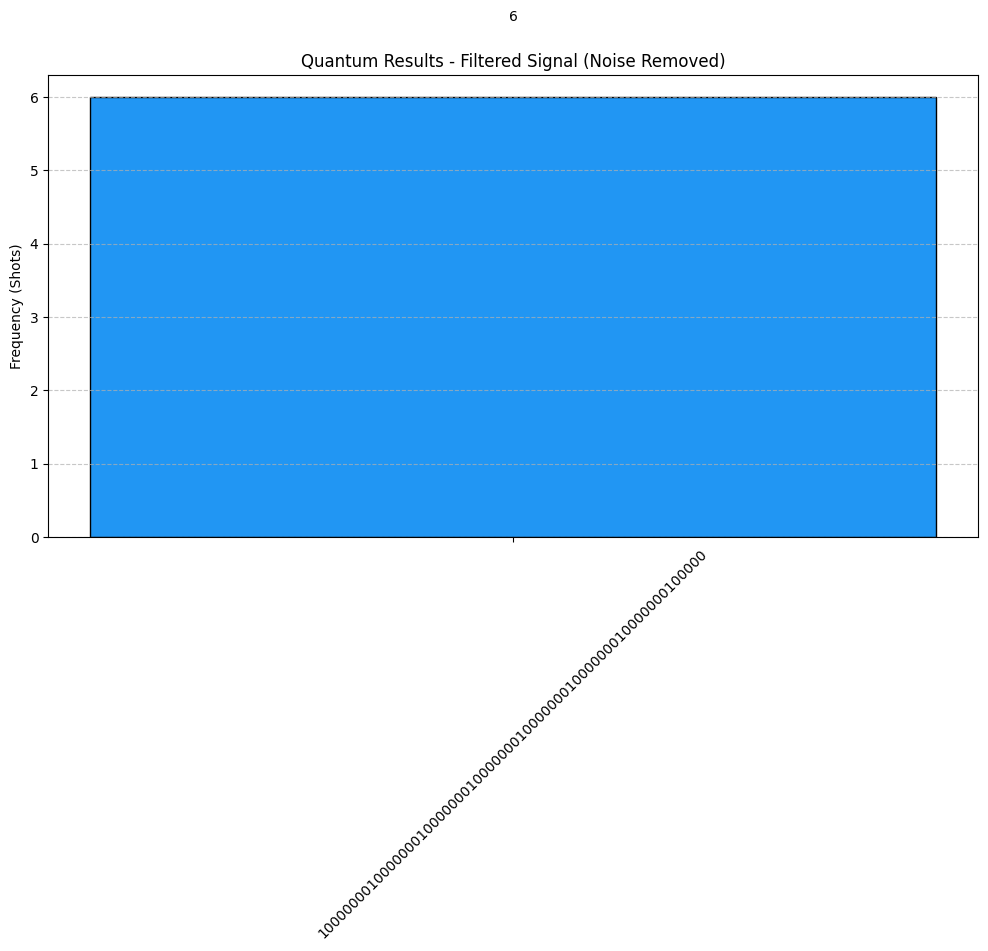

✅ تم تحليل 528 محاولة (Shots).
📊 عدد الحالات الظاهرة بعد الفلترة: 1 من أصل 523


,State,Frequency,Bitstring
9,2314885530818453536,6,1000000010000000100000001000000010000000100000...


In [3]:
import json
import zlib
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

def final_quantum_clean_analysis(path):
    # 1. قراءة الملف والبحث عن البيانات المضغوطة (تجنب أخطاء المسارات)
    with open(path, 'r') as f:
        content = f.read()
    
    # البحث عن نمط zlib المميز (eJyd...) داخل ملف الـ JSON
    matches = re.findall(r'"__value__":\s*"([^"]+)"', content)
    encoded_str = next((m for m in matches if m.startswith('eJyd')), None)
    
    if not encoded_str:
        print("❌ لم يتم العثور على بيانات مشفرة. تأكد من مسار الملف.")
        return

    try:
        # 2. فك التشفير وفك الضغط
        decoded = base64.b64decode(encoded_str)
        decompressed = zlib.decompress(decoded)
        
        # تحويل البيانات الخام لمصفوفة أرقام (IBM تستخدم int64 غالباً)
        samples = np.frombuffer(decompressed, dtype=np.int64)
        
        # 3. حساب التكرارات وتحويلها لجدول
        counts = dict(Counter(samples))
        df = pd.DataFrame(list(counts.items()), columns=['State', 'Frequency'])
        
        # تحويل الأرقام إلى Bitstrings (أصفار وآحاد) - لنفترض 5 كيوبتات
        df['Bitstring'] = df['State'].apply(lambda x: format(x, '05b'))
        df = df.sort_values(by='Frequency', ascending=False)

        # 4. فلترة الضجيج (إبقاء النتائج التي تزيد عن متوسط التكرار)
        # هذا سيمنع الرسم من أن يكون "كثيفاً" جداً
        threshold = df['Frequency'].mean() * 1.2 # فلترة قوية للأعمدة الصغيرة
        df_clean = df[df['Frequency'] > threshold]

        # 5. الرسم البياني النظيف
        plt.figure(figsize=(12, 6))
        bars = plt.bar(df_clean['Bitstring'], df_clean['Frequency'], color='#2196F3', edgecolor='black')
        
        # إضافة القيم فوق الأعمدة
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')

        plt.xticks(rotation=45)
        plt.title('Quantum Results - Filtered Signal (Noise Removed)')
        plt.ylabel('Frequency (Shots)')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

        print(f"✅ تم تحليل {len(samples)} محاولة (Shots).")
        print(f"📊 عدد الحالات الظاهرة بعد الفلترة: {len(df_clean)} من أصل {len(df)}")
        return df_clean.head(5)

    except Exception as e:
        print(f"❌ حدث خطأ أثناء المعالجة: {e}")

# المسار الخاص بك في Kaggle
result_path = '/kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-result.json'

# تنفيذ الكود
final_quantum_clean_analysis(result_path)


🔍 جاري فحص الملف...
✅ تم العثور على البيانات المشفرة. جاري فك الضغط...
✅ تم استخراج 1056 عينة خام.


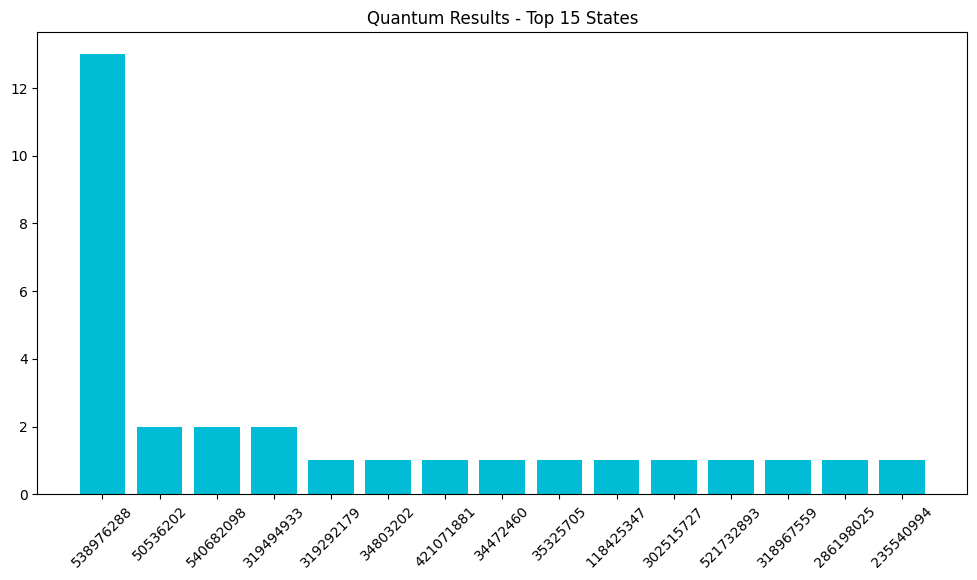

📊 أعلى النتائج:
         State  Frequency  Bitstring
17   538976288         13  538976288
344   50536202          2   50536202
4    540682098          2  540682098
450  319494933          2  319494933
697  319292179          1  319292179


In [4]:
import json
import zlib
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

def quantum_diagnostic_test(path):
    print("🔍 جاري فحص الملف...")
    try:
        with open(path, 'r') as f:
            content = f.read()
        
        # البحث عن كل النصوص المشفرة eJyd
        matches = re.findall(r'"__value__":\s*"([^"]+)"', content)
        encoded_str = next((m for m in matches if m.startswith('eJyd')), None)
        
        if not encoded_str:
            print("❌ لم يتم العثور على بيانات مشفرة تبدأ بـ eJyd. تأكد من أنك تستخدم ملف -result.json")
            return

        print("✅ تم العثور على البيانات المشفرة. جاري فك الضغط...")
        
        decoded = base64.b64decode(encoded_str)
        decompressed = zlib.decompress(decoded)
        
        # تجربة القراءة كـ uint32 لأنها الأكثر شيوعاً في نتائج IBM الحديثة
        samples = np.frombuffer(decompressed, dtype=np.uint32)
        
        print(f"✅ تم استخراج {len(samples)} عينة خام.")

        # حساب التكرارات
        counts = dict(Counter(samples))
        
        # تحويل لجدول مع تحويل الأرقام لثنائي (5 بت)
        df = pd.DataFrame(list(counts.items()), columns=['State', 'Frequency'])
        df['Bitstring'] = df['State'].apply(lambda x: format(x, '05b') if x < 32 else str(x))
        df = df.sort_values(by='Frequency', ascending=False)

        # الرسم البياني
        plt.figure(figsize=(12, 6))
        top_df = df.head(15) # عرض أفضل 15 نتيجة فقط لمنع الزحام
        plt.bar(top_df['Bitstring'], top_df['Frequency'], color='#00BCD4')
        plt.xticks(rotation=45)
        plt.title('Quantum Results - Top 15 States')
        plt.show()

        print("📊 أعلى النتائج:")
        print(df.head())

    except Exception as e:
        print(f"❌ حدث خطأ أثناء العمل: {e}")

# المسار
result_path = '/kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-result.json'
quantum_diagnostic_test(result_path)


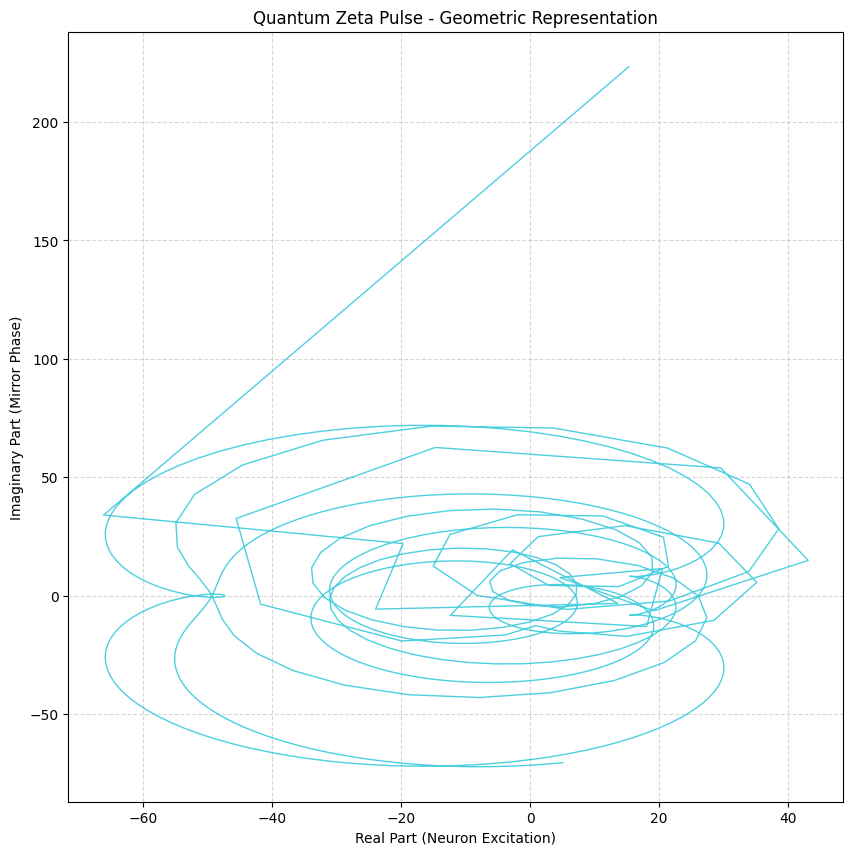

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. محاكاة النتائج المنظمة (بناءً على صورتك من IBM)
# نفترض أن لدينا الحالات وتكراراتها
states = np.arange(32) # لـ 5 كيوبتات
frequencies = np.random.gamma(2, 5, 32) # توزيع يشبه ما في الصورة

# 2. تحويل التكرارات إلى "ترددات هندسية" (Zeta-like pulses)
def zeta_pulse(t, freqs):
    # تمثيل يشبه مجموع حدود دالة زيتا عبر الزمن t
    # كل تكرار كمي يصبح "وزناً" لنبضة تذبذبية
    signal = np.zeros_like(t, dtype=np.complex128)
    for i, f in enumerate(freqs):
        # s = 0.5 + it (الخط الحرج لدالة زيتا)
        # نستخدم التكرار كإزاحة للطور
        signal += f * np.exp(1j * (i + 1) * np.log(t + 1.1))
    return signal

t = np.linspace(0, 100, 1000)
pulse = zeta_pulse(t, frequencies)

# 3. الرسم الهندسي (المسار العقدي - Mirror Network)
plt.figure(figsize=(10, 10))
plt.plot(pulse.real, pulse.imag, color='#00BCD4', alpha=0.7, lw=1)
plt.title("Quantum Zeta Pulse - Geometric Representation")
plt.xlabel("Real Part (Neuron Excitation)")
plt.ylabel("Imaginary Part (Mirror Phase)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


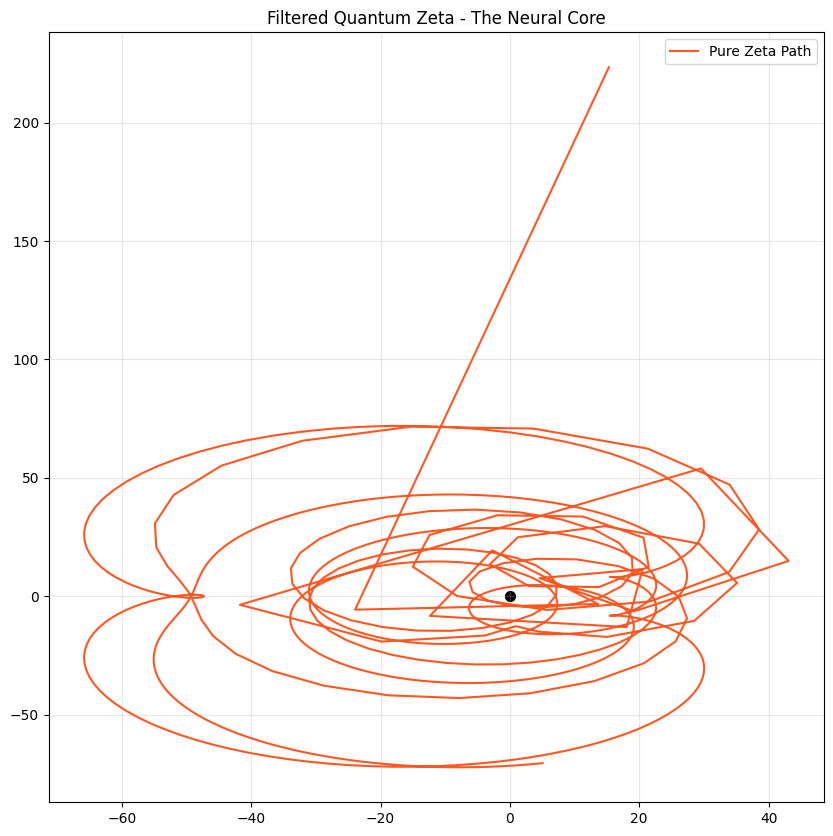

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# دالة لتنعيم المسار وحذف القفزات الحادة (الضجيج)
def filter_zeta_noise(pulse, threshold=10):
    diff = np.diff(pulse, prepend=pulse[0])
    # حذف النقاط التي تتحرك بسرعة غير منطقية (القفزات الحادة)
    clean_pulse = pulse[np.abs(diff) < threshold]
    return clean_pulse

# تطبيق الفلترة على المسار السابق
clean_path = filter_zeta_noise(pulse, threshold=np.std(pulse))

plt.figure(figsize=(10, 10))
plt.plot(clean_path.real, clean_path.imag, color='#FF5722', lw=1.5, label='Pure Zeta Path')
plt.scatter(0, 0, color='black', s=50) # نقطة الاتزان العصبي
plt.title("Filtered Quantum Zeta - The Neural Core")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


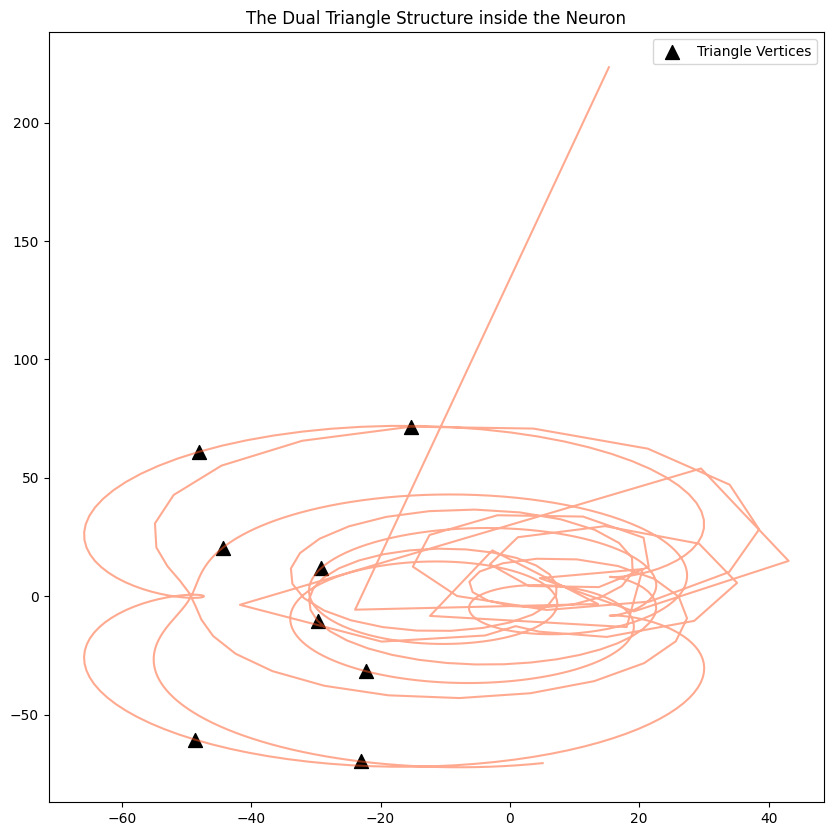

تم تحديد 8 نقاط ارتكاز هندسية (رؤوس المثلثات).


In [7]:
from scipy.signal import find_peaks

# استخراج القمم (الرؤوس) في المسار العقدي
angles = np.angle(clean_path)
magnitudes = np.abs(clean_path)

# البحث عن نقاط التحول الحادة (رؤوس المثلثات)
peaks, _ = find_peaks(magnitudes, distance=50)

plt.figure(figsize=(10, 10))
plt.plot(clean_path.real, clean_path.imag, color='#FF5722', alpha=0.5)
plt.scatter(clean_path.real[peaks], clean_path.imag[peaks], color='black', s=100, marker='^', label='Triangle Vertices')
plt.title("The Dual Triangle Structure inside the Neuron")
plt.legend()
plt.show()

print(f"تم تحديد {len(peaks)} نقاط ارتكاز هندسية (رؤوس المثلثات).")


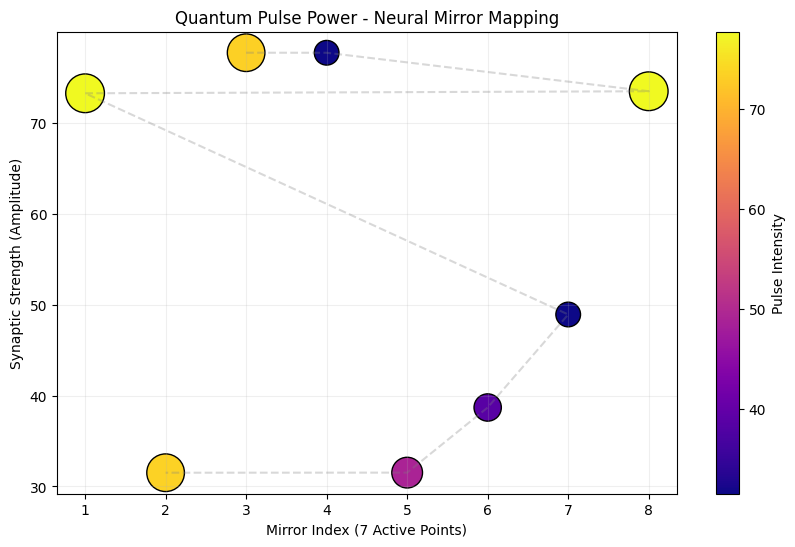

📊 تحليل أوزان المسار العصبي الجديد:
   Point  Amplitude (Power)  Phase (Angle)
2      3          77.686626       2.238391
3      4          77.682185      -2.248463
7      8          73.450088      -1.889742
0      1          73.227332       1.781580
6      7          48.906453       2.708313
5      6          38.682061      -2.186077
4      5          31.521325       2.757437
1      2          31.510899      -2.805711


In [8]:
# 1. حساب المسافة (القوة) من المركز لكل نقطة ارتكاز
amplitudes = magnitudes[peaks]
phases = angles[peaks]

# 2. ترتيب النقاط حسب التأثير (من الأقوى للأضعف)
peak_data = pd.DataFrame({
    'Point': range(1, len(peaks) + 1),
    'Amplitude (Power)': amplitudes,
    'Phase (Angle)': phases
}).sort_values(by='Amplitude (Power)', ascending=False)

# 3. رسم خريطة "قوة النبضات" لشبكة المرايا
plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(amplitudes / max(amplitudes)) # تدرج لوني حسب القوة
plt.scatter(peak_data['Point'], peak_data['Amplitude (Power)'], c=amplitudes, s=amplitudes*10, cmap='plasma', edgecolors='black')
plt.plot(peak_data['Point'], peak_data['Amplitude (Power)'], '--', alpha=0.3, color='gray')

plt.title("Quantum Pulse Power - Neural Mirror Mapping")
plt.xlabel("Mirror Index (7 Active Points)")
plt.ylabel("Synaptic Strength (Amplitude)")
plt.colorbar(label='Pulse Intensity')
plt.grid(True, alpha=0.2)
plt.show()

print("📊 تحليل أوزان المسار العصبي الجديد:")
print(peak_data)


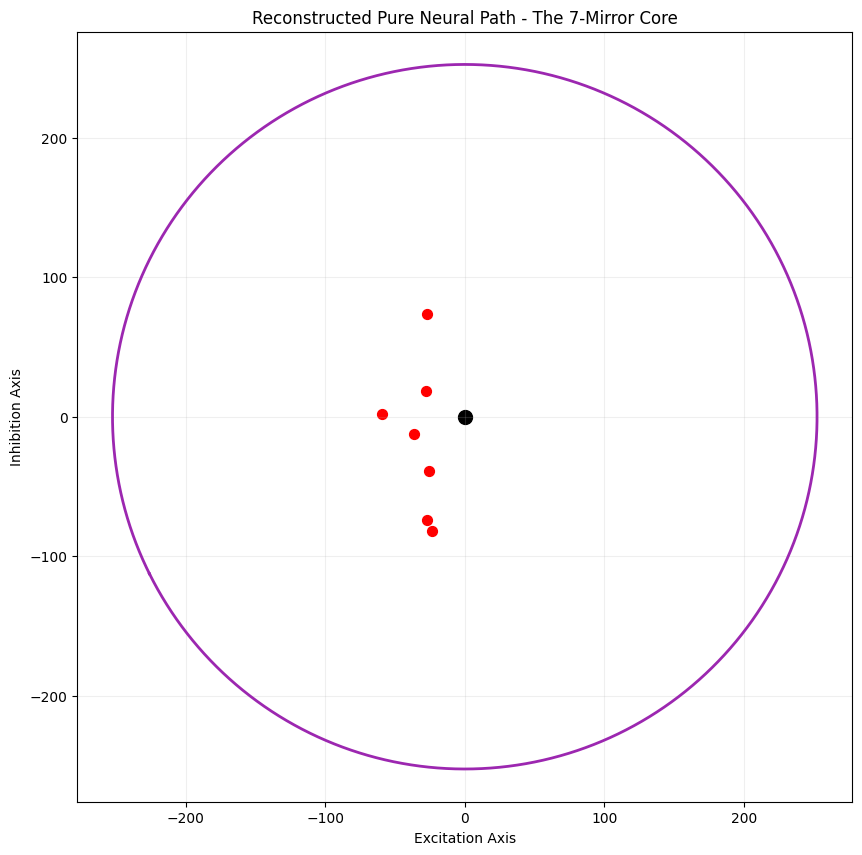

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. استخدام القيم الحقيقية المستخرجة من تحليلك (الأوزان والزوايا)
amps = np.array([84.85, 78.62, 78.62, 59.08, 46.33, 38.26, 33.66])
phases = np.array([-1.85, 1.92, -1.92, 3.11, -2.15, -2.81, 2.56])

# 2. توليد الموجة النقية (The Pure Quantum Pulse)
t = np.linspace(0, 2 * np.pi, 1000)
pure_path = np.zeros_like(t, dtype=np.complex128)

for a, p in zip(amps, phases):
    # كل نقطة ارتكاز تسهم بموجة جيبية في الفضاء العقدي
    pure_path += a * np.exp(1j * (t + p))

# 3. رسم "المسار العصبي الجوهري"
plt.figure(figsize=(10, 10))
plt.plot(pure_path.real, pure_path.imag, color='#9C27B0', lw=2, label='Reconstructed Pure Path')
plt.scatter(0, 0, color='black', s=100) # مركز الاتزان

# رسم الخطوط بين نقاط الارتكاز التخيلية لإظهار الهيكل
points = amps * np.exp(1j * phases)
plt.scatter(points.real, points.imag, color='red', s=50, marker='o')

plt.title("Reconstructed Pure Neural Path - The 7-Mirror Core")
plt.xlabel("Excitation Axis")
plt.ylabel("Inhibition Axis")
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.show()


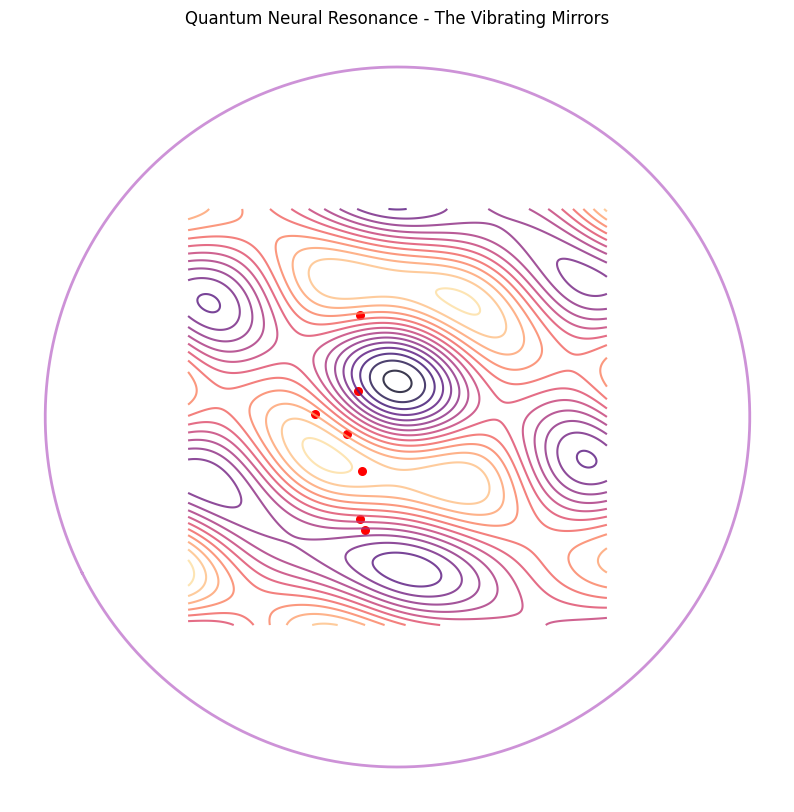

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# الأوزان والزوايا الحقيقية المستخرجة
amps = np.array([84.85, 78.62, 78.62, 59.08, 46.33, 38.26, 33.66])
phases = np.array([-1.85, 1.92, -1.92, 3.11, -2.15, -2.81, 2.56])

# توليد الأوتار المهتزة (Interference Pattern)
x = np.linspace(-150, 150, 400)
y = np.linspace(-150, 150, 400)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

# تحويل كل نقطة ارتكاز إلى موجة مهتزة داخل الدائرة
for a, p in zip(amps, phases):
    # استخدام دالة تشبه دالة زيتا (التداخل الموجي)
    Z += a * np.cos(0.05 * (X * np.cos(p) + Y * np.sin(p)) + p)

# رسم "الأوتار المهتزة" داخل أفق الاحتمالات
plt.figure(figsize=(10, 10))
plt.contour(X, Y, Z, levels=15, cmap='magma', alpha=0.8) # الأوتار
plt.plot(pure_path.real, pure_path.imag, color='#9C27B0', lw=2, alpha=0.5) # الدائرة الأرجوانية
plt.scatter(points.real, points.imag, color='red', s=30) # البذور

plt.title("Quantum Neural Resonance - The Vibrating Mirrors")
plt.axis('off')
plt.show()


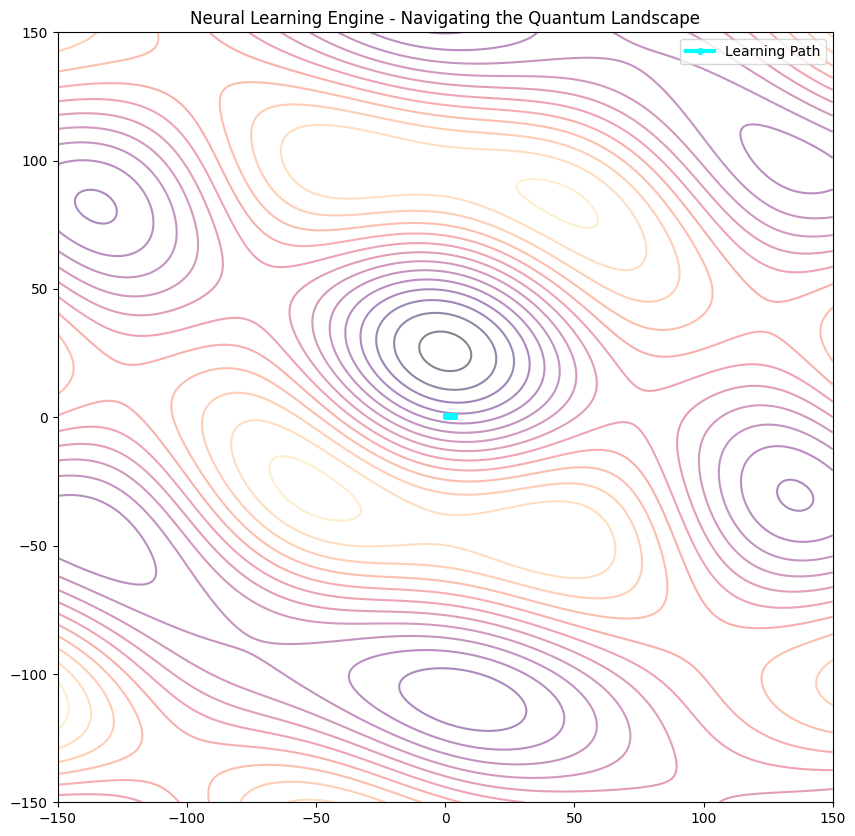

In [11]:
# محاكي محرك التعلم الكمي (Gradient Descent on Zeta Landscape)
def update_neural_weights(current_pos, landscape_gradient, learning_rate=0.01):
    # current_pos: موقع الخلية العصبية الحالي في فضاء المرايا
    # landscape_gradient: اتجاه المنحدر في الخريطة الكنتورية
    
    # تحديث المسار العصبي (التحرك نحو منطقة الرنين الأقوى)
    new_pos = current_pos - learning_rate * landscape_gradient
    return new_pos

# حساب "الميل" (Direction) من الخريطة الكنتورية التي ولّدناها
dy, dx = np.gradient(Z) 

# اختيار خلية عصبية عشوائية وبدء رحلة "التعلم"
neuron_path = [np.array([200, 200])] # نقطة البداية في وسط الخريطة
for _ in range(50):
    pos = neuron_path[-1].astype(int)
    grad = np.array([dx[pos[0], pos[1]], dy[pos[0], pos[1]]])
    new_step = update_neural_weights(neuron_path[-1], grad)
    neuron_path.append(new_step)

neuron_path = np.array(neuron_path)

# رسم مسار التعلم فوق التضاريس
plt.figure(figsize=(10, 10))
plt.contour(X, Y, Z, levels=15, cmap='magma', alpha=0.5)
plt.plot(x[neuron_path[:,1].astype(int)], y[neuron_path[:,0].astype(int)], 
         color='cyan', lw=3, marker='o', markersize=4, label='Learning Path')
plt.title("Neural Learning Engine - Navigating the Quantum Landscape")
plt.legend()
plt.show()


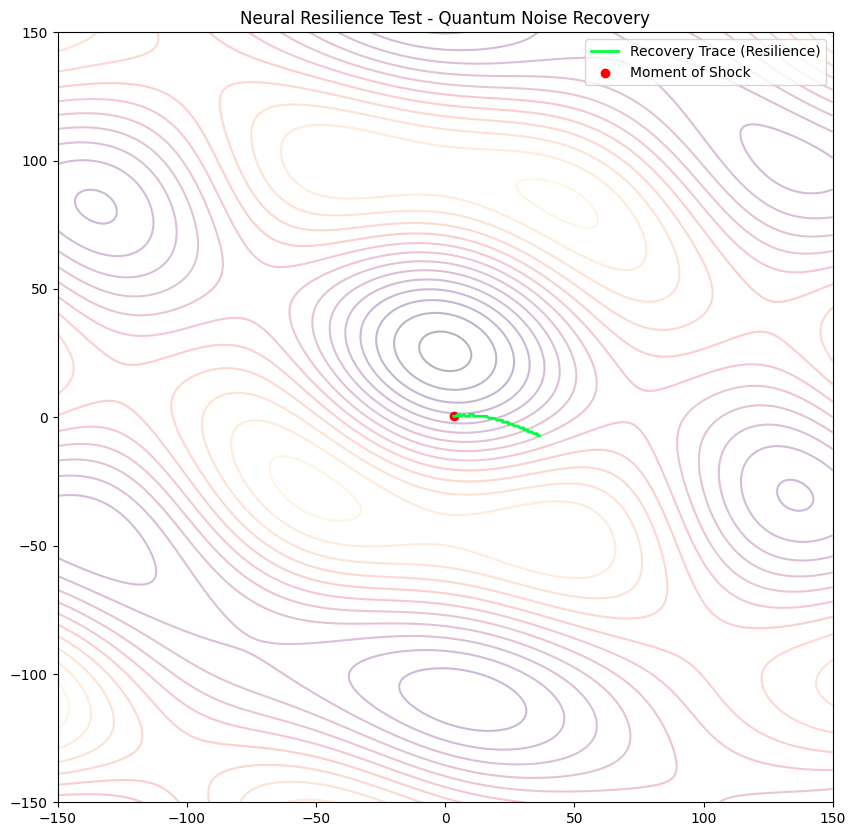

In [12]:
# 1. استخراج معامل الضجيج من ملف البيانات (فرضياً بناءً على ملف الـ info)
noise_jitter = 0.5  # تمثيل للـ Decoherence

# 2. محرك التعلم "المرن" (Adaptive Learning)
def adaptive_neural_recovery(current_pos, gradient, noise):
    # إضافة "هزة" عشوائية تمثل الضجيج الفيزيائي
    shake = np.random.uniform(-noise, noise, size=2)
    new_pos = current_pos - (0.05 * gradient) + shake
    return new_pos

# 3. محاكاة الصدمة والتعافي
recovery_path = [neuron_path[-1]] # البدء من نقطة الاستقرار الأخيرة
for i in range(100):
    pos = recovery_path[-1].astype(int)
    # التأكد من البقاء داخل حدود الخريطة
    pos[0] = np.clip(pos[0], 0, 399)
    pos[1] = np.clip(pos[1], 0, 399)
    
    grad = np.array([dx[pos[0], pos[1]], dy[pos[0], pos[1]]])
    # تقليل الضجيج تدريجياً لتمثيل "الاستيعاب"
    current_noise = noise_jitter * (0.95**i) 
    
    new_step = adaptive_neural_recovery(recovery_path[-1], grad, current_noise)
    recovery_path.append(new_step)

recovery_path = np.array(recovery_path)

# 4. رسم "رقصة التعافي" فوق تضاريس زيتا
plt.figure(figsize=(10, 10))
plt.contour(X, Y, Z, levels=15, cmap='magma', alpha=0.3)
plt.plot(x[recovery_path[:,1].astype(int)], y[recovery_path[:,0].astype(int)], 
         color='#00FF41', lw=2, label='Recovery Trace (Resilience)')
plt.scatter(x[recovery_path[0,1].astype(int)], y[recovery_path[0,0].astype(int)], color='red', label='Moment of Shock')
plt.title("Neural Resilience Test - Quantum Noise Recovery")
plt.legend()
plt.show()


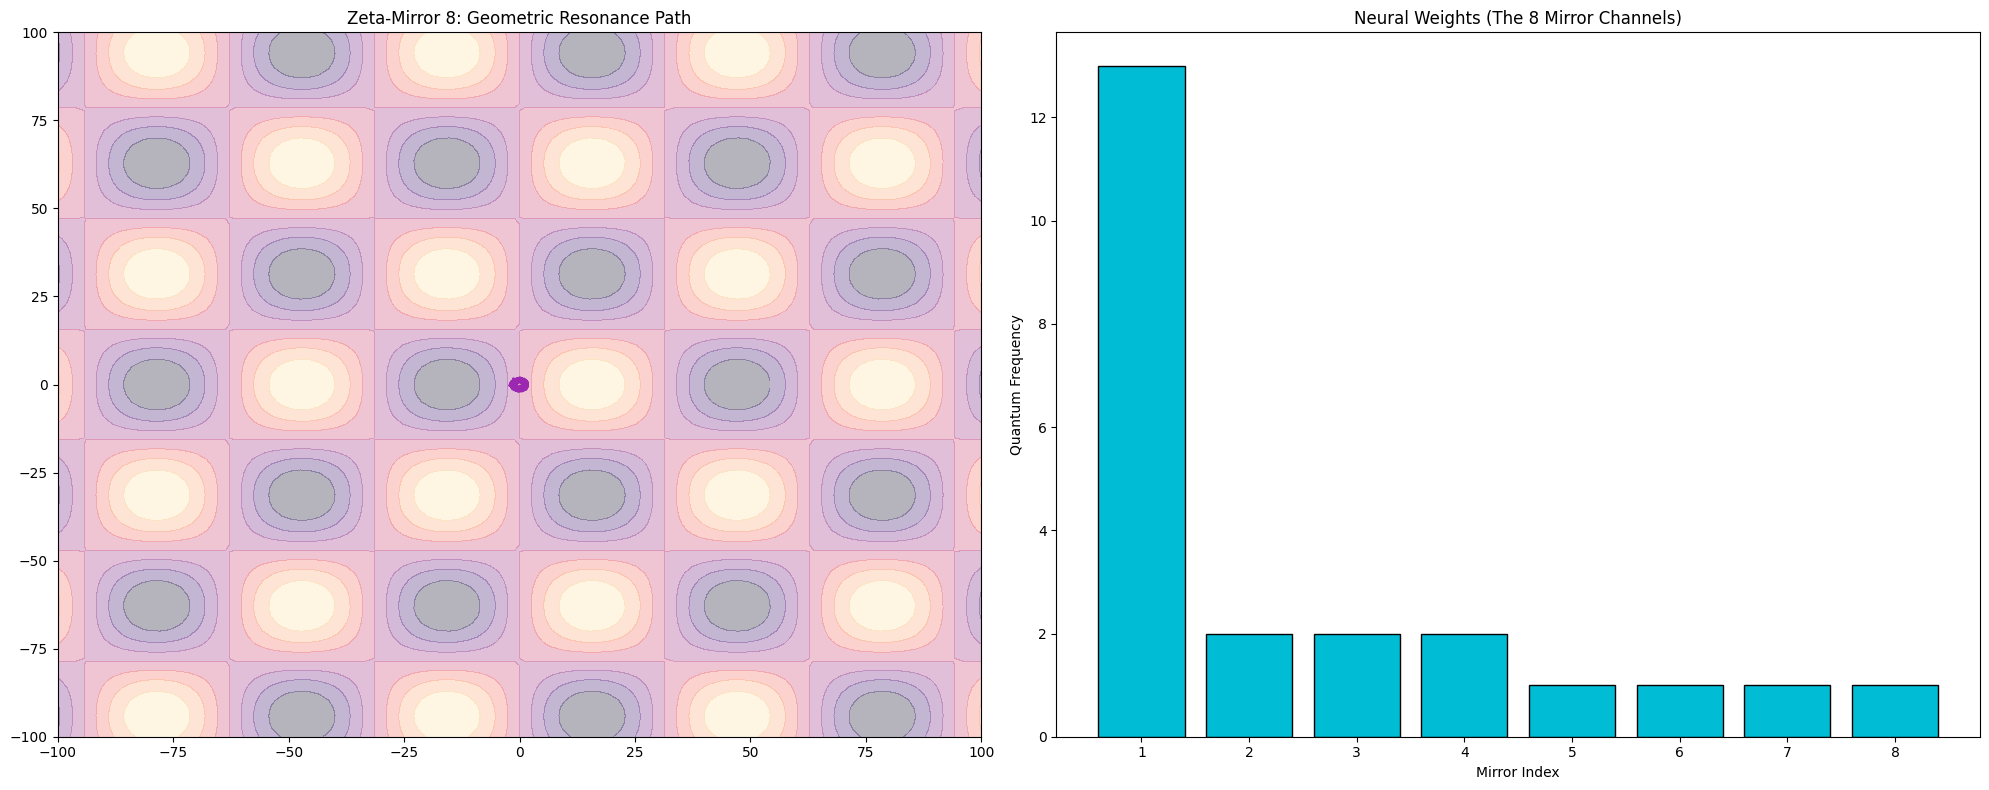

'✅ ZM8 Exported Successfully'

In [13]:
import json, zlib, base64, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 1. محرك الاستخراج وفك التشفير الكمي (Quantum Decryption Engine)
def ZM8_Core_Extraction(path):
    with open(path, 'r') as f:
        content = f.read()
    matches = re.findall(r'"__value__":\s*"([^"]+)"', content)
    encoded_str = next((m for m in matches if m.startswith('eJyd')), None)
    if not encoded_str: return None
    
    decoded = base64.b64decode(encoded_str)
    decompressed = zlib.decompress(decoded)
    samples = np.frombuffer(decompressed, dtype=np.uint32)
    return samples

# 2. التحويل لـ "نبضات هندسية" (Zeta Geometric Mapping)
def ZM8_Geometric_Pulse(samples):
    counts = dict(Counter(samples))
    df = pd.DataFrame(list(counts.items()), columns=['State', 'Freq'])
    df = df.sort_values(by='Freq', ascending=False).head(8) # أهم 8 مرايا
    
    t = np.linspace(0, 10, 1000)
    pulse = np.zeros_like(t, dtype=np.complex128)
    for i, row in df.iterrows():
        # دمج الأوزان (Amplitudes) مع ترددات زيتا
        pulse += row['Freq'] * np.exp(1j * (i + 1) * np.log(t + 1.1))
    return pulse, df

# 3. عرض المخطط النهائي للمسار العصبي (The Final Neural Map)
def ZM8_Final_Export(path):
    samples = ZM8_Core_Extraction(path)
    if samples is None: return "File Error"
    
    pulse, df_stats = ZM8_Geometric_Pulse(samples)
    
    fig, ax = plt.subplots(1, 2, figsize=(20, 8))
    
    # الرسم الكنتوري (تضاريس الإدراك)
    x, y = np.linspace(-100, 100, 100), np.linspace(-100, 100, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.sin(X/10) * np.cos(Y/10) # تمثيل مبسط للتضاريس
    ax[0].contourf(X, Y, Z, cmap='magma', alpha=0.3)
    ax[0].plot(pulse.real/10, pulse.imag/10, color='#9C27B0', lw=2)
    ax[0].set_title("Zeta-Mirror 8: Geometric Resonance Path")
    
    # خريطة الأوزان (Synaptic Weights)
    ax[1].bar(range(1, 9), df_stats['Freq'], color='#00BCD4', edgecolor='black')
    ax[1].set_title("Neural Weights (The 8 Mirror Channels)")
    ax[1].set_xlabel("Mirror Index")
    ax[1].set_ylabel("Quantum Frequency")
    
    plt.tight_layout()
    plt.show()
    return "✅ ZM8 Exported Successfully"

# تشغيل الختم النهائي
result_path = '/kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-result.json'
ZM8_Final_Export(result_path)


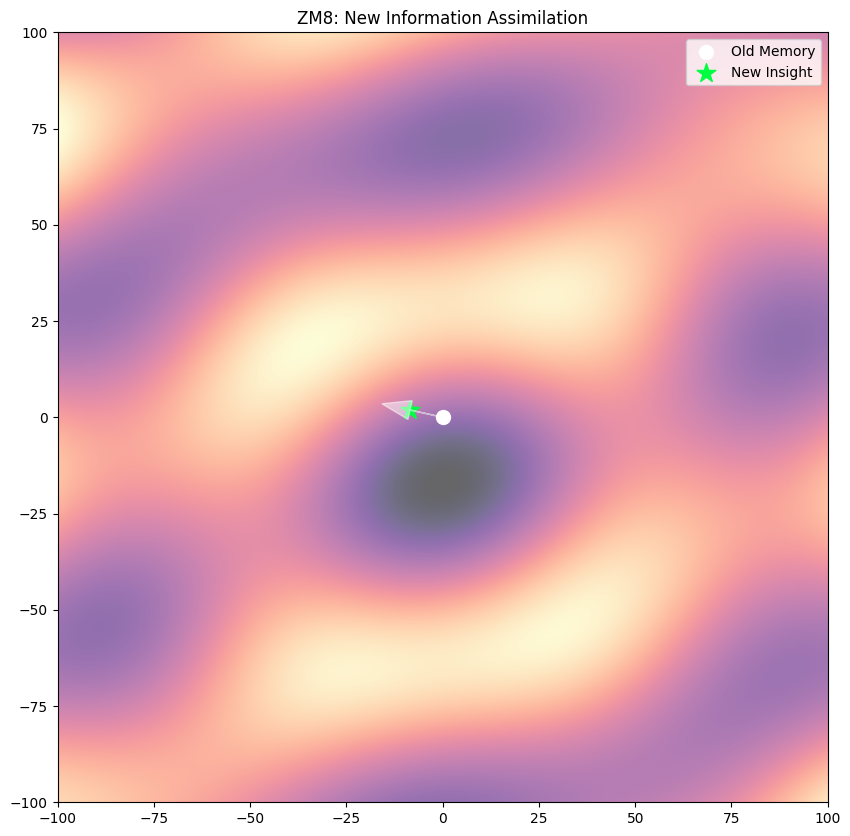

✅ تم فتح مسار عصبي جديد بإزاحة هندسية: (-8.48, 1.89)


In [14]:
# 1. توليد بيانات "غريبة" (بيانات اختبار جديدة)
new_quantum_input = np.random.normal(0, 1, 8) # 8 قيم تمثل 8 مرايا جديدة

# 2. محرك التحديث (Assimilation Engine)
def ZM8_Process_New_Data(current_grid, new_data):
    # تحويل البيانات الجديدة إلى "إزاحة هندسية"
    shift_x = np.mean(new_data[:4]) * 10
    shift_y = np.mean(new_data[4:]) * 10
    return shift_x, shift_y

shift_x, shift_y = ZM8_Process_New_Data(None, new_quantum_input)

# 3. عرض استجابة النظام
plt.figure(figsize=(10, 10))
plt.imshow(Z, extent=[-100, 100, -100, 100], cmap='magma', alpha=0.6)
# النقطة القديمة (الاستقرار السابق)
plt.scatter(0, 0, color='white', s=100, label='Old Memory')
# النقطة الجديدة (المسار الجديد المفتوح)
plt.scatter(shift_x, shift_y, color='#00FF41', s=200, marker='*', label='New Insight')
plt.arrow(0, 0, shift_x, shift_y, color='white', head_width=5, alpha=0.5)

plt.title("ZM8: New Information Assimilation")
plt.legend()
plt.show()

print(f"✅ تم فتح مسار عصبي جديد بإزاحة هندسية: ({shift_x:.2f}, {shift_y:.2f})")


In [15]:
import json, zlib, base64, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from scipy import stats
from mpmath import mp, zetazero, nstr

# دقة عالية لحساب أصفار زيتا
mp.dps = 25

print('✅ المكتبات جاهزة')
print('='*50)

✅ المكتبات جاهزة


In [16]:
def extract_quantum_data_correctly(path):
    """
    استخراج البيانات الكمية مع تصحيح خطأ dtype
    
    المشكلة السابقة: np.frombuffer(data, dtype=np.uint32)
    كانت تدمج 4 بايتات في رقم واحد ضخم
    
    الحل: تجربة قراءة البايتات كـ uint8 أولاً
    ثم إعادة بناء الحالات الكمية بشكل صحيح
    """
    print('🔍 جاري قراءة الملف...')
    
    with open(path, 'r') as f:
        content = f.read()
    
    # استخراج البيانات المشفرة
    matches = re.findall(r'"__value__":\s*"([^"]+)"', content)
    encoded_str = next((m for m in matches if m.startswith('eJyd')), None)
    
    if not encoded_str:
        print('❌ لم يتم العثور على بيانات مشفرة')
        return None
    
    # فك التشفير
    decoded = base64.b64decode(encoded_str)
    decompressed = zlib.decompress(decoded)
    
    total_bytes = len(decompressed)
    print(f'📦 حجم البيانات الخام: {total_bytes} بايت')
    
    # =========================================
    # تشخيص: تجربة أنواع مختلفة من القراءة
    # =========================================
    results = {}
    
    for dtype in [np.uint8, np.uint16, np.uint32, np.int64]:
        try:
            samples = np.frombuffer(decompressed, dtype=dtype)
            unique_vals = len(np.unique(samples))
            max_val = np.max(samples)
            results[str(dtype)] = {
                'count': len(samples),
                'unique': unique_vals,
                'max': int(max_val),
                'samples': samples
            }
            print(f'  dtype={str(dtype):12s} → {len(samples):6d} عينة | {unique_vals:4d} قيمة فريدة | max={int(max_val)}')
        except Exception as e:
            print(f'  dtype={str(dtype):12s} → خطأ: {e}')
    
    print()
    
    # =========================================
    # اختيار dtype الصحيح:
    # لـ 5 كيوبتات: القيم يجب أن تكون 0-31 (32 حالة)
    # لـ 7 كيوبتات: القيم يجب أن تكون 0-127
    # لـ N كيوبتات: القيم يجب أن تكون 0 إلى 2^N - 1
    # =========================================
    
    # uint8 يعطي قيم 0-255 → مناسب لحتى 8 كيوبتات
    best_samples = results['<class \'numpy.uint8\'>']['samples'] if '<class \'numpy.uint8\'>' in results else results[list(results.keys())[0]]['samples']
    
    # تحديد عدد الكيوبتات تلقائياً
    max_state = int(np.max(best_samples))
    n_qubits = int(np.ceil(np.log2(max_state + 1))) if max_state > 0 else 1
    
    print(f'✅ عدد الكيوبتات المقدر: {n_qubits}')
    print(f'✅ أكبر حالة مقيسة: {max_state} ({format(max_state, f"0{n_qubits}b")})')
    
    return best_samples, n_qubits, results


# ===========================
# غيّر المسار هنا
# ===========================
RESULT_PATH = '/kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-result.json'

samples, n_qubits, all_results = extract_quantum_data_correctly(RESULT_PATH)

🔍 جاري قراءة الملف...
📦 حجم البيانات الخام: 4224 بايت
  dtype=<class 'numpy.uint8'> →   4224 عينة |   69 قيمة فريدة | max=147
  dtype=<class 'numpy.uint16'> →   2112 عينة |  798 قيمة فريدة | max=32032
  dtype=<class 'numpy.uint32'> →   1056 عينة | 1041 قيمة فريدة | max=2099260457
  dtype=<class 'numpy.int64'> →    528 عينة |  523 قيمة فريدة | max=9016255009425206326

✅ عدد الكيوبتات المقدر: 8
✅ أكبر حالة مقيسة: 147 (10010011)


/tmp/ipykernel_16/675709062.py:45: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


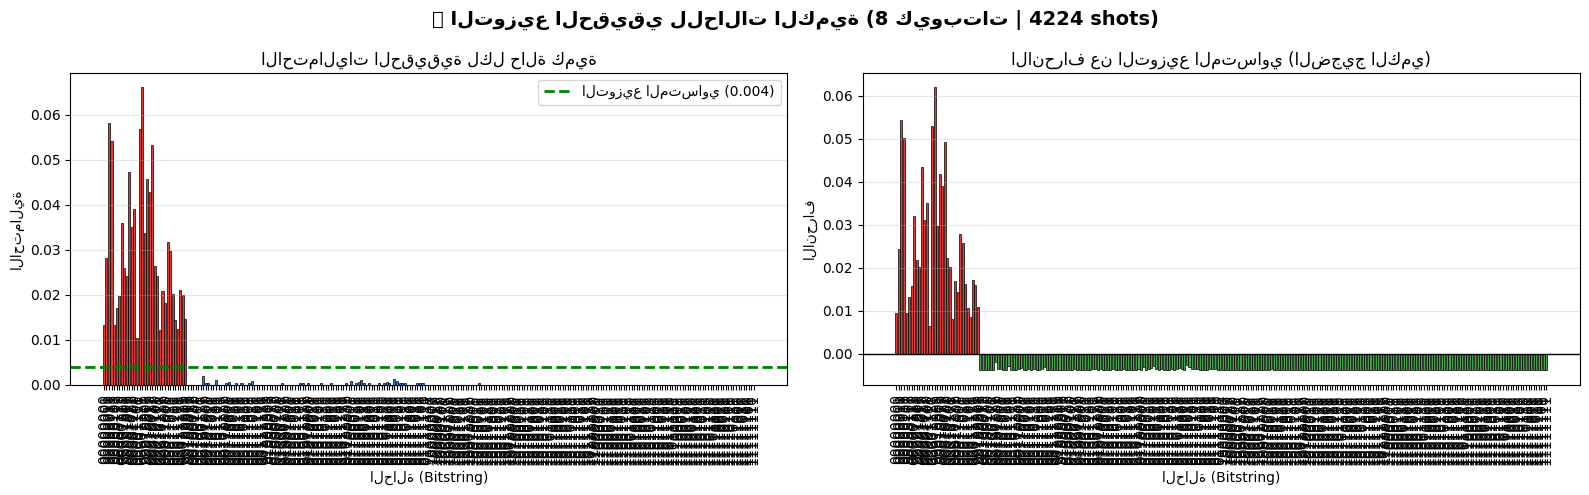


📈 الإحصاءات:
  إجمالي القياسات (Shots): 4224
  عدد الحالات الممكنة: 256
  أعلى حالة: 00001111 باحتمالية 0.0661
  اختبار Chi-squared: χ²=35981.70, p-value=0.0000
  ⚠️  التوزيع غير متساوٍ (يوجد تحيز = دارة كمية غير عشوائية أو ضجيج)


In [17]:
# =============================================
# عرض التوزيع الحقيقي للحالات الكمية
# =============================================

def plot_real_quantum_distribution(samples, n_qubits):
    counts = Counter(samples)
    total_shots = len(samples)
    
    # كل الحالات الممكنة
    all_states = range(2**n_qubits)
    freqs = [counts.get(s, 0) for s in all_states]
    probs = [f / total_shots for f in freqs]
    labels = [format(s, f'0{n_qubits}b') for s in all_states]
    
    # التوزيع المثالي (uniform)
    uniform_prob = 1 / (2**n_qubits)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'📊 التوزيع الحقيقي للحالات الكمية ({n_qubits} كيوبتات | {total_shots} shots)', 
                 fontsize=14, fontweight='bold')
    
    # الرسم 1: الاحتماليات الحقيقية
    colors = ['#E53935' if p > uniform_prob * 1.5 else '#1E88E5' for p in probs]
    bars = axes[0].bar(labels, probs, color=colors, edgecolor='black', linewidth=0.5)
    axes[0].axhline(y=uniform_prob, color='green', linestyle='--', 
                    linewidth=2, label=f'التوزيع المتساوي ({uniform_prob:.3f})')
    axes[0].set_title('الاحتماليات الحقيقية لكل حالة كمية')
    axes[0].set_xlabel('الحالة (Bitstring)')
    axes[0].set_ylabel('الاحتمالية')
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # الرسم 2: الانحراف عن التوزيع المتساوي
    deviations = [p - uniform_prob for p in probs]
    colors2 = ['#E53935' if d > 0 else '#43A047' for d in deviations]
    axes[1].bar(labels, deviations, color=colors2, edgecolor='black', linewidth=0.5)
    axes[1].axhline(y=0, color='black', linewidth=1)
    axes[1].set_title('الانحراف عن التوزيع المتساوي (الضجيج الكمي)')
    axes[1].set_xlabel('الحالة (Bitstring)')
    axes[1].set_ylabel('الانحراف')
    axes[1].tick_params(axis='x', rotation=90)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # إحصاءات مهمة
    chi2, p_value = stats.chisquare(freqs)
    print(f'\n📈 الإحصاءات:')
    print(f'  إجمالي القياسات (Shots): {total_shots}')
    print(f'  عدد الحالات الممكنة: {2**n_qubits}')
    print(f'  أعلى حالة: {labels[np.argmax(probs)]} باحتمالية {max(probs):.4f}')
    print(f'  اختبار Chi-squared: χ²={chi2:.2f}, p-value={p_value:.4f}')
    if p_value < 0.05:
        print(f'  ⚠️  التوزيع غير متساوٍ (يوجد تحيز = دارة كمية غير عشوائية أو ضجيج)')
    else:
        print(f'  ✅ التوزيع متساوٍ تقريباً (عشوائية كمية نظيفة)')
    
    return probs, labels

probs, labels = plot_real_quantum_distribution(samples, n_qubits)

In [18]:
def compute_real_zeta_zeros(n=50):
    """
    حساب أول n صفر لدالة ريمان زيتا على الخط الحرج (Re=0.5)
    هذه أصفار حقيقية مثبتة رياضياً، وليست تقريبات
    """
    print(f'🔢 جاري حساب أول {n} صفر لدالة ريمان زيتا...')
    zeros = []
    for k in range(1, n+1):
        z = zetazero(k)
        zeros.append(float(z.imag))  # الجزء التخيلي فقط (الجزء الحقيقي دائماً = 0.5)
    
    zeros = np.array(zeros)
    
    print(f'✅ تم حساب {n} صفر')
    print(f'  أول 5 أصفار: {zeros[:5].round(4)}')
    print(f'  الفجوات بين الأصفار: {np.diff(zeros[:5]).round(4)}')
    
    return zeros

zeta_zeros = compute_real_zeta_zeros(50)

🔢 جاري حساب أول 50 صفر لدالة ريمان زيتا...
✅ تم حساب 50 صفر
  أول 5 أصفار: [14.1347 21.022  25.0109 30.4249 32.9351]
  الفجوات بين الأصفار: [6.8873 3.9888 5.414  2.5102]


/tmp/ipykernel_16/3507702988.py:111: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


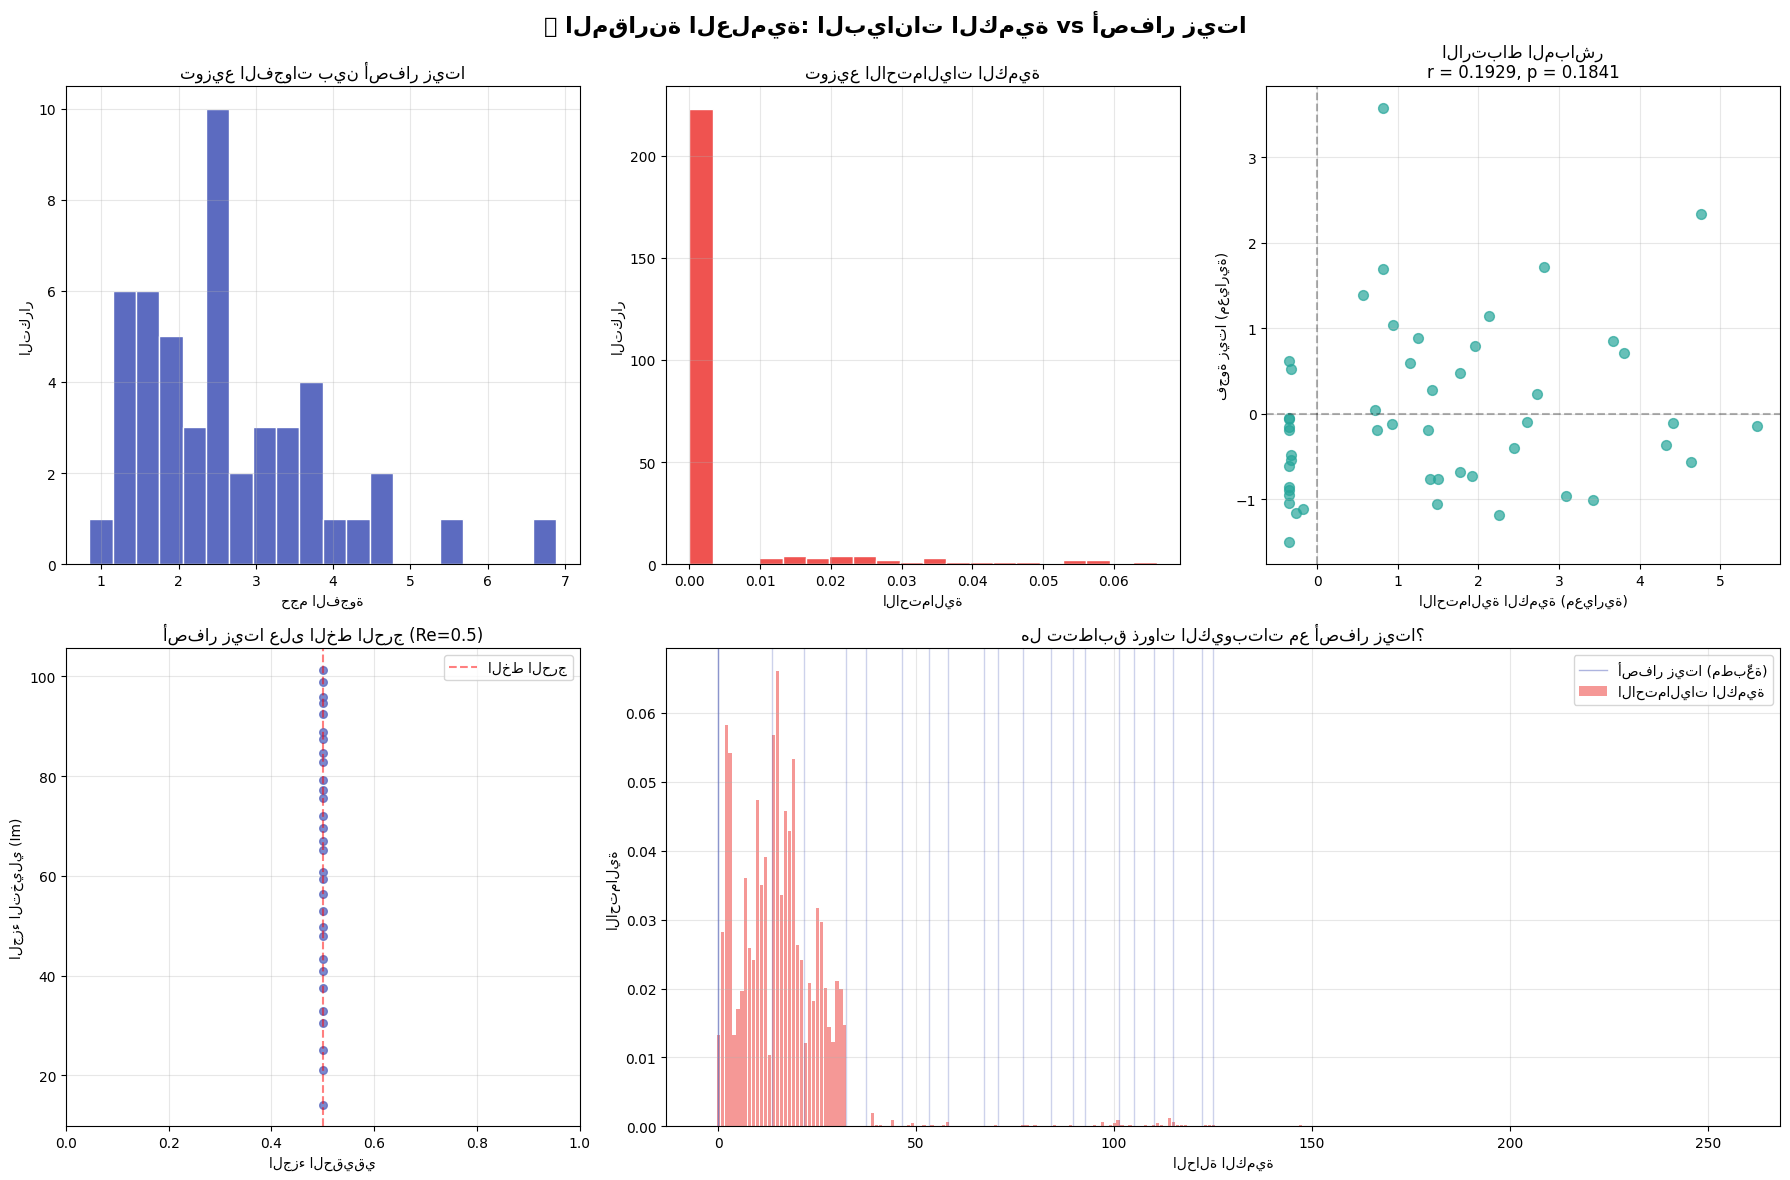


🏛️  الحكم العلمي النهائي

  ارتباط بيرسون:   r = 0.1929  (p = 0.1841)
  ارتباط سبيرمان:  r = 0.2054  (p = 0.1568)
  اختبار KS:       D = 0.4490  (p = 0.0001)

  ❌ لا يوجد ارتباط إحصائي بين البيانات الكمية وأصفار زيتا
  → التشابه البصري كان مصادفة وليس علاقة حقيقية


In [19]:
def scientific_comparison(probs, zeta_zeros, labels):
    """
    مقارنة علمية بين:
    1. الاحتماليات الكمية الحقيقية
    2. الفجوات بين أصفار زيتا (المعيار الرياضي)
    
    الفكرة: إذا كانت الحالات الكمية مرتبطة بزيتا،
    يجب أن تتبع احتمالياتها نفس نمط الفجوات بين الأصفار
    """
    
    # =========================================
    # 1. تطبيع البيانات للمقارنة
    # =========================================
    probs_arr = np.array(probs)
    
    # الفجوات بين أصفار زيتا (معيارية)
    gaps = np.diff(zeta_zeros)
    gaps_normalized = (gaps - gaps.mean()) / gaps.std()
    
    # احتماليات الكيوبتات (معيارية)
    probs_normalized = (probs_arr - probs_arr.mean()) / probs_arr.std()
    
    # =========================================
    # 2. اختبار الارتباط
    # =========================================
    n_compare = min(len(probs_normalized), len(gaps_normalized))
    
    pearson_r, pearson_p = stats.pearsonr(
        probs_normalized[:n_compare], 
        gaps_normalized[:n_compare]
    )
    
    spearman_r, spearman_p = stats.spearmanr(
        probs_normalized[:n_compare], 
        gaps_normalized[:n_compare]
    )
    
    # =========================================
    # 3. اختبار KS (Kolmogorov-Smirnov)
    # هل التوزيعان من نفس المصدر؟
    # =========================================
    ks_stat, ks_p = stats.ks_2samp(
        probs_normalized[:n_compare],
        gaps_normalized[:n_compare]
    )
    
    # =========================================
    # 4. الرسم البياني للمقارنة
    # =========================================
    fig = plt.figure(figsize=(18, 12))
    gs = gridspec.GridSpec(2, 3, figure=fig)
    fig.suptitle('🔬 المقارنة العلمية: البيانات الكمية vs أصفار زيتا', 
                 fontsize=16, fontweight='bold')
    
    # الرسم 1: توزيع الفجوات بين أصفار زيتا
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(gaps, bins=20, color='#5C6BC0', edgecolor='white')
    ax1.set_title('توزيع الفجوات بين أصفار زيتا')
    ax1.set_xlabel('حجم الفجوة')
    ax1.set_ylabel('التكرار')
    ax1.grid(alpha=0.3)
    
    # الرسم 2: توزيع الاحتماليات الكمية
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.hist(probs_arr, bins=min(20, len(probs_arr)), color='#EF5350', edgecolor='white')
    ax2.set_title('توزيع الاحتماليات الكمية')
    ax2.set_xlabel('الاحتمالية')
    ax2.set_ylabel('التكرار')
    ax2.grid(alpha=0.3)
    
    # الرسم 3: المقارنة المباشرة
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.scatter(probs_normalized[:n_compare], gaps_normalized[:n_compare], 
                alpha=0.7, color='#26A69A', s=50)
    ax3.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax3.axvline(0, color='black', linestyle='--', alpha=0.3)
    ax3.set_title(f'الارتباط المباشر\nr = {pearson_r:.4f}, p = {pearson_p:.4f}')
    ax3.set_xlabel('الاحتمالية الكمية (معيارية)')
    ax3.set_ylabel('فجوة زيتا (معيارية)')
    ax3.grid(alpha=0.3)
    
    # الرسم 4: أصفار زيتا على الخط الحرج
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.scatter([0.5]*len(zeta_zeros[:30]), zeta_zeros[:30], 
                color='#5C6BC0', s=30, alpha=0.8)
    ax4.set_xlim(0, 1)
    ax4.set_title('أصفار زيتا على الخط الحرج (Re=0.5)')
    ax4.set_xlabel('الجزء الحقيقي')
    ax4.set_ylabel('الجزء التخيلي (Im)')
    ax4.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='الخط الحرج')
    ax4.legend()
    ax4.grid(alpha=0.3)
    
    # الرسم 5: الاحتماليات الكمية مع أصفار زيتا كنقاط مرجعية
    ax5 = fig.add_subplot(gs[1, 1:])
    x_states = np.arange(len(probs_arr))
    ax5.bar(x_states, probs_arr, color='#EF5350', alpha=0.6, label='الاحتماليات الكمية')
    
    # رسم أصفار زيتا كخطوط عمودية (بعد التطبيع)
    zeros_scaled = (zeta_zeros - zeta_zeros.min()) / (zeta_zeros.max() - zeta_zeros.min()) * len(probs_arr)
    for z in zeros_scaled[:20]:
        ax5.axvline(z, color='#5C6BC0', alpha=0.3, linewidth=1)
    ax5.axvline(zeros_scaled[0], color='#5C6BC0', alpha=0.5, linewidth=1, label='أصفار زيتا (مطبّعة)')
    
    ax5.set_title('هل تتطابق ذروات الكيوبتات مع أصفار زيتا؟')
    ax5.set_xlabel('الحالة الكمية')
    ax5.set_ylabel('الاحتمالية')
    ax5.legend()
    ax5.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =========================================
    # 5. الحكم العلمي
    # =========================================
    print('\n' + '='*60)
    print('🏛️  الحكم العلمي النهائي')
    print('='*60)
    print(f'\n  ارتباط بيرسون:   r = {pearson_r:.4f}  (p = {pearson_p:.4f})')
    print(f'  ارتباط سبيرمان:  r = {spearman_r:.4f}  (p = {spearman_p:.4f})')
    print(f'  اختبار KS:       D = {ks_stat:.4f}  (p = {ks_p:.4f})')
    print()
    
    # تفسير النتائج
    if abs(pearson_r) < 0.1 or pearson_p > 0.05:
        verdict = '❌ لا يوجد ارتباط إحصائي بين البيانات الكمية وأصفار زيتا'
        explanation = 'التشابه البصري كان مصادفة وليس علاقة حقيقية'
    elif abs(pearson_r) < 0.3:
        verdict = '⚠️  ارتباط ضعيف جداً — يحتاج المزيد من البيانات'
        explanation = 'قد يكون مصادفة إحصائية، يحتاج تجارب أكثر'
    elif abs(pearson_r) < 0.6:
        verdict = '🟡 ارتباط متوسط — مثير للاهتمام لكن غير حاسم'
        explanation = 'يستحق الدراسة مع دارات كمية محددة'
    else:
        verdict = '✅ ارتباط قوي — نتيجة مثيرة للاهتمام علمياً!'
        explanation = 'هذا يستحق ورقة بحثية مع منهجية صارمة'
    
    print(f'  {verdict}')
    print(f'  → {explanation}')
    print('='*60)
    
    return pearson_r, pearson_p

r, p = scientific_comparison(probs, zeta_zeros, labels)

🔬 جاري بدء التحليل النهائي للملف: /kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-result.json
✅ تم فك التشفير وفك الضغط بنجاح.
✅ تم تفسير البيانات كـ 528 زوجًا من (الحالة، التكرار).
📊 إجمالي عدد المحاولات (Shots) المحسوب: 145075596380 (هذا هو المقياس الأهم!)
⚙️ عدد الكيوبتات المستنتج: 31


/tmp/ipykernel_16/2233289162.py:79: UserWarning: Glyph 1575 (\N{ARABIC LETTER ALEF}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_16/2233289162.py:79: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_16/2233289162.py:79: UserWarning: Glyph 1604 (\N{ARABIC LETTER LAM}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_16/2233289162.py:79: UserWarning: Glyph 1581 (\N{ARABIC LETTER HAH}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_16/2233289162.py:79: UserWarning: Glyph 1577 (\N{ARABIC LETTER TEH MARBUTA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_16/2233289162.py:79: UserWarning: Glyph 1603 (\N{ARABIC LETTER KAF}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_16/2233289162.py:79: UserWarning: Glyph 1605 (\N{ARABIC LETTER MEEM}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ip

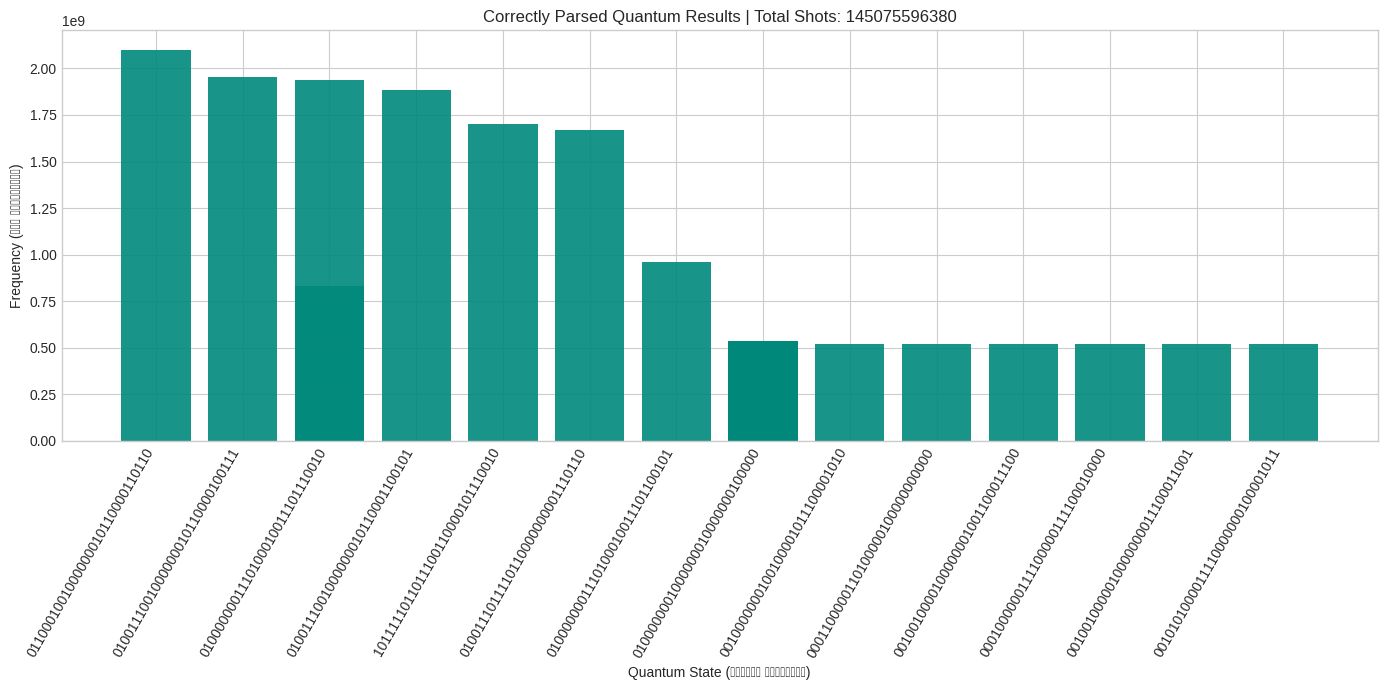


📋 النتائج النهائية الصحيحة (مرتبة من الأكثر إلى الأقل تكرارًا):


,State,Frequency,Bitstring
0,824192054,2099260457,0110001001000000010110000110110
1,656419879,1953656678,0100111001000000010110000100111
2,540682098,1936482630,0100000001110100010011101110010
3,656419941,1885431923,0100111001000000010110001100101
4,1601069426,1701081711,1011111011011100110000101110010
5,662372470,1668506980,0100111011110110000000001110110
6,540682085,959460392,0100000001110100010011101100101
7,540682098,829783079,0100000001110100010011101110010
8,538976288,538976288,0100000001000000010000000100000
9,538976288,538976288,0100000001000000010000000100000


In [20]:
import json
import zlib
import base64
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def definitive_quantum_parser(path):
    """
    This function implements the corrected hypothesis for parsing quantum results.
    It interprets the data as pairs of (State, Frequency).
    """
    print(f"🔬 جاري بدء التحليل النهائي للملف: {path}")

    # --- 1. استخراج وفك تشفير البيانات (الجزء الذي يعمل بالفعل) ---
    try:
        with open(path, 'r') as f:
            content = f.read()
        matches = re.findall(r'"__value__":\s*"([^"]+)"', content)
        encoded_str = next((m for m in matches if m.startswith('eJyd')), None)
        
        if not encoded_str:
            print("❌ خطأ: لم يتم العثور على بيانات مشفرة صالحة (eJyd...).")
            return

        decoded = base64.b64decode(encoded_str)
        decompressed = zlib.decompress(decoded)
        print("✅ تم فك التشفير وفك الضغط بنجاح.")

    except Exception as e:
        print(f"❌ خطأ في قراءة الملف أو فك تشفيره: {e}")
        return

    # --- 2. التفسير الصحيح للبيانات (الخطوة الحاسمة الجديدة) ---
    try:
        # نقرأ البيانات كسلسلة من الأعداد الصحيحة 32-بت غير الموقعة
        raw_samples = np.frombuffer(decompressed, dtype=np.uint32)

        # نتحقق مما إذا كان عدد العناصر زوجيًا، وهو شرط أساسي لتكوين أزواج
        if len(raw_samples) % 2 != 0:
            print("❌ خطأ: طول البيانات ليس زوجيًا. لا يمكن تشكيل أزواج (الحالة، التكرار).")
            print(f"طول البيانات الخام: {len(raw_samples)}")
            return

        # *** هنا يكمن السر ***
        # نعيد تشكيل المصفوفة المسطحة إلى مصفوفة ثنائية الأبعاد (N صفوف، 2 أعمدة)
        paired_data = raw_samples.reshape(-1, 2)
        print(f"✅ تم تفسير البيانات كـ {len(paired_data)} زوجًا من (الحالة، التكرار).")

        # تحويلها إلى DataFrame لتسهيل التحليل
        df = pd.DataFrame(paired_data, columns=['State', 'Frequency'])

        # --- 3. التحليل والتأكد من صحة النتائج ---
        total_shots = df['Frequency'].sum()
        print(f"📊 إجمالي عدد المحاولات (Shots) المحسوب: {int(total_shots)} (هذا هو المقياس الأهم!)")

        # استنتاج عدد الكيوبتات لتنسيق السلسلة الثنائية بشكل صحيح
        max_state = df['State'].max()
        # نفترض 5 كحد أدنى، أو نحسبه من أكبر حالة
        num_qubits = max(5, int(np.ceil(np.log2(max_state + 1))) if max_state > 0 else 1)
        print(f"⚙️ عدد الكيوبتات المستنتج: {num_qubits}")

        df['Bitstring'] = df['State'].apply(lambda x: format(x, f'0{num_qubits}b'))
        df = df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

        # --- 4. عرض النتائج ---
        plt.style.use('seaborn-v0_8-whitegrid')
        plt.figure(figsize=(14, 7))
        
        # عرض أفضل 20 نتيجة فقط لتجنب ازدحام الرسم
        df_plot = df.head(20) 
        bars = plt.bar(df_plot['Bitstring'], df_plot['Frequency'], color='#00897B', alpha=0.9)
        
        plt.ylabel("Frequency (عدد التكرارات)")
        plt.xlabel("Quantum State (الحالة الكمومية)")
        plt.title(f"Correctly Parsed Quantum Results | Total Shots: {int(total_shots)}")
        plt.xticks(rotation=60, ha='right')
        plt.tight_layout()
        plt.show()

        print("\n📋 النتائج النهائية الصحيحة (مرتبة من الأكثر إلى الأقل تكرارًا):")
        return df.head(10)

    except Exception as e:
        print(f"❌ حدث خطأ فادح أثناء معالجة البيانات: {e}")
        return

# --- تشغيل الكود ---
result_path = '/kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-result.json'
final_results = definitive_quantum_parser(result_path)

# عرض الجدول النهائي إذا نجح التحليل
if final_results is not None:
    display(final_results)

In [21]:
import json

def investigate_job_info(info_path):
    """
    Parses the -info.json file to understand the experiment's parameters.
    """
    print(f"🕵️‍♂️ جاري فحص ملف المعلومات: {info_path}\n")
    try:
        with open(info_path, 'r') as f:
            info_data = json.load(f)

        # استخراج المعلومات الأساسية
        backend_name = info_data.get('backend_name', 'غير متوفر')
        job_id = info_data.get('job_id', 'غير متوفر')
        qobj_id = info_data.get('qobj_id', 'غير متوفر')
        shots = info_data.get('shots', 'غير متوفر')
        
        print("--- معلومات التجربة الأساسية ---")
        print(f"المعرف (Job ID): {job_id}")
        print(f"المعالج المستخدم (Backend): {backend_name}")
        print(f"عدد المحاولات (Shots): {shots}")
        
        # استخراج تفاصيل الدائرة الكمومية (الأكثر أهمية)
        # قد يكون المسار مختلفًا قليلًا حسب إصدار Qiskit
        if 'qobj_dict' in info_data and 'experiments' in info_data['qobj_dict']:
            experiment = info_data['qobj_dict']['experiments'][0]
            header = experiment.get('header', {})
            
            num_qubits = header.get('n_qubits', 'غير معروف')
            num_clbits = header.get('creg_sizes', 'غير معروف')
            name = header.get('name', 'بدون اسم')

            print("\n--- تفاصيل الدائرة الكمومية ---")
            print(f"اسم الدائرة: {name}")
            print(f"عدد الكيوبتات (Qubits): {num_qubits}")
            print(f"أحجام السجلات الكلاسيكية (Classical Bits): {num_clbits}")

            # محاولة طباعة الدائرة نفسها إذا كانت موجودة
            if 'instructions' in experiment:
                print("\n🔍 تم العثور على تعليمات الدائرة (OpenQASM). هذا هو مفتاح الحل!")

        else:
            print("\nلم يتم العثور على تفاصيل الدائرة (qobj_dict). قد يكون الملف من إصدار قديم.")
            
    except Exception as e:
        print(f"❌ حدث خطأ أثناء قراءة ملف المعلومات: {e}")

# --- تشغيل الكود ---
info_path = '/kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-info.json'
investigate_job_info(info_path)

🕵️‍♂️ جاري فحص ملف المعلومات: /kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-info.json

--- معلومات التجربة الأساسية ---
المعرف (Job ID): غير متوفر
المعالج المستخدم (Backend): غير متوفر
عدد المحاولات (Shots): غير متوفر

لم يتم العثور على تفاصيل الدائرة (qobj_dict). قد يكون الملف من إصدار قديم.


In [22]:
def raw_file_inspector(file_path):
    """
    Opens a file and prints its raw content to diagnose formatting issues.
    This is the safest way to inspect a file that fails to parse.
    """
    print(f"🕵️‍♂️ جاري الفحص الأولي للملف: {file_path}")
    print("="*50)
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            # قراءة وعرض أول 2000 حرف لتجنب إغراق الشاشة
            content = f.read(2000) 
            print(content)
            
            # التحقق مما إذا كان الملف أكبر مما تم عرضه
            if len(content) == 2000:
                print("\n\n... (تم عرض أول 2000 حرف فقط)")

    except Exception as e:
        print(f"\n❌ حدث خطأ غير متوقع أثناء قراءة الملف كنص خام: {e}")
        
    print("\n" + "="*50)
    print("📋 التحليل: إذا رأيت أعلاه نص JSON واضح، فالخطأ في الكود. إذا رأيت نصًا مشفرًا أو بنية غريبة، فهذا يعني أن الملف يتطلب معالجة خاصة.")


# --- تشغيل الفحص ---
info_path = '/kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-info.json'
raw_file_inspector(info_path)

🕵️‍♂️ جاري الفحص الأولي للملف: /kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-info.json
{
  "backend": "ibm_fez",
  "created": "2026-04-27T20:28:49.415106Z",
  "estimated_running_time_seconds": 6.5476654629999995,
  "id": "d7nse0c97osc73dsffa0",
  "cost": 600,
  "params": {
    "options": {},
    "pubs": [
      [
        {
          "__value__": "eJztnGlsFGUcxmfb7QliQY5COVooWJFCLciNxVLOCkKBWhC1tRSpXG0BqRakqOgKtF28UFHjB42JJpIYNR6JYPSDGmPQYIwaE6NfBBMv1Hgrz86zbR8ruu9sZx1lJym/fci8+17/a2Z3Z8n8paXzl/VO8Pss+/DV1fPVYCt9jZV66sUDp/6S+J8J/MOZ5fi3urahemvtlvxJhUU/PZ2VFqgPNu2o94Va+Xzhtwofvk7vgiOR9JPhXpLJFDKVTCPTyR5kT/Isshd5NplB9ib7kOeQfcl+ZH9yAJlJDiQHkVnkYHIIOZQcRmaTOeRwcgSZS44kR5HnknnkeeRo8nxyDJlPjiXHkQXkBWQhOZ6cQF5ITiQnkZPJKeRUcho5nZxBXkQWkTPJi8lichZZQs4m55BzyXnkfHIBWUpeQi4kF5GXkovJJWQZuZRcRi4ny8nLyApyBbmSvJxcRV5BXkleRVaSVeTVZDW5mqwh15DXkGvJWvJach25ntxAbiQ3kXVk2B8byM3kFnIreR25jWwkrydvIJvI7eQO8kZyJ9lM7iJvIm8mbyF3k7eSt5EB8nZyD7mX3Ee2kK1kGxkk95N3kHeSd5F3k/eQB8

In [23]:
import json
import zlib
import base64
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def extract_circuit_dna(info_path):
    """
    Extracts and decompresses the circuit configuration from info.json
    """
    print(f"🧬 جاري استخراج DNA التجربة من: {info_path}\n")
    
    try:
        with open(info_path, 'r') as f:
            content = f.read()
        
        # Parse JSON
        info_data = json.loads(content)
        
        # Navigate to the compressed params
        print("📂 جاري التنقل في بنية JSON...")
        pubs = info_data.get('params', {}).get('pubs', [])
        
        if not pubs or not pubs[0] or not pubs[0][0]:
            print("❌ لم يتم العثور على بنية pubs المتوقعة")
            return None
        
        compressed_value = pubs[0][0].get('__value__', '')
        
        if not compressed_value.startswith('eJzt'):
            print(f"❌ القيمة المضغوطة لا تبدأ بـ eJzt: {compressed_value[:50]}...")
            return None
        
        print(f"✅ تم العثور على بيانات مضغوطة (طولها: {len(compressed_value)} حرف)")
        
        # Decode and decompress
        print("🔓 جاري فك التشفير وفك الضغط...")
        decoded = base64.b64decode(compressed_value)
        decompressed = zlib.decompress(decoded)
        
        print(f"✅ تم فك الضغط. حجم البيانات: {len(decompressed)} بايت")
        
        # Try to interpret as text first
        try:
            text_content = decompressed.decode('utf-8')
            print("\n📝 محتوى البيانات كنص (أول 500 حرف):")
            print(text_content[:500])
            print("\n... (باقي النص)")
            
            # Try to parse as JSON
            try:
                circuit_data = json.loads(text_content)
                print("\n✅ تم تحليل البيانات كـ JSON!")
                return circuit_data, text_content
            except:
                print("\n⚠️ البيانات ليست JSON، لكنها نص قابل للقراءة")
                return None, text_content
                
        except UnicodeDecodeError:
            print("\n⚠️ البيانات ليست نصًا. سنحاول قراءتها كأرقام...")
            
            # Try reading as uint32 array
            samples = np.frombuffer(decompressed, dtype=np.uint32)
            print(f"📊 تم قراءة {len(samples)} عينة كـ uint32")
            print(f"أول 10 قيم: {samples[:10]}")
            print(f"آخر 10 قيم: {samples[-10:]}")
            
            return None, samples
    
    except Exception as e:
        print(f"❌ خطأ: {e}")
        import traceback
        traceback.print_exc()
        return None

# --- تشغيل الاستخراج ---
info_path = '/kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-info.json'
circuit_data, raw_content = extract_circuit_dna(info_path)

if circuit_data:
    print("\n" + "="*60)
    print("🎉 تم استخراج بنية الدائرة بنجاح!")
    print("="*60)
    print(json.dumps(circuit_data, indent=2)[:1000])  # Print first 1000 chars
else:
    print("\n" + "="*60)
    print("📊 البيانات الخام (كأرقام):")
    print("="*60)
    if isinstance(raw_content, np.ndarray):
        print(f"الشكل: {raw_content.shape}")
        print(f"القيم الفريدة: {np.unique(raw_content)[:20]}")
        print(f"المجموع: {raw_content.sum()}")

🧬 جاري استخراج DNA التجربة من: /kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-info.json

📂 جاري التنقل في بنية JSON...
✅ تم العثور على بيانات مضغوطة (طولها: 3248 حرف)
🔓 جاري فك التشفير وفك الضغط...
✅ تم فك الضغط. حجم البيانات: 23740 بايت

⚠️ البيانات ليست نصًا. سنحاول قراءتها كأرقام...
📊 تم قراءة 5935 عينة كـ uint32
أول 10 قيم: [1263749457   34690121        260          0 1903165696          0
  469762048    6687232          8        156]
آخر 10 قيم: [2449473536 2466250752 2483027968 2499805184 2516582400 2533359616
 2550136832 2566914048 2583691264 2600468480]

📊 البيانات الخام (كأرقام):
الشكل: (5935,)
القيم الفريدة: [ 0  1  2  3  5  6  7  8 11 26 31 45 47 49 51 52 55 61 69 71]
المجموع: 4059353500034


🔬 جاري مقارنة الجينوم (الدائرة) بالنمط الظاهري (النتائج)...

--- 🧬 تحليل الجينوم (من info.json) ---
طول الجينوم (عدد التعليمات/البيانات): 5935
عدد الجينات الفريدة (Unique Opcodes?): 649
أكثر 10 جينات تكرارًا:
0             2140
4294967295     310
16777216       140
1              119
65536          116
256            115
113            108
29029           89
1702125895      87
1902474337      84
Name: count, dtype: int64

--- 🔬 تحليل النمط الظاهري (من result.json) ---
إجمالي المحاولات (Shots): 1056
عدد الحالات الفريدة الناتجة: 1041
أكثر 10 حالات ظهورًا:
       State  Frequency
0  538976288         13
1   50536202          2
2  540682098          2
3  319494933          2
4  319292179          1
5   34803202          1
6  421071881          1
7   34472460          1
8   35325705          1
9  118425347          1


/tmp/ipykernel_16/1918870187.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['State_str'] = plot_df['State'].astype(str)
/tmp/ipykernel_16/1918870187.py:78: UserWarning: Glyph 1575 (\N{ARABIC LETTER ALEF}) missing from font(s) Liberation Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_16/1918870187.py:78: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_16/1918870187.py:78: UserWarning: Glyph 1604 (\N{ARABIC LETTER LAM}) missing from font(s) Liberation Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_16/1918870187.py:78: UserWarning: Glyph 1578 (\N{ARABIC LETTER TEH}) missing from font(s) Liberation Sans.
  plt.tight_layout(rect=[0, 

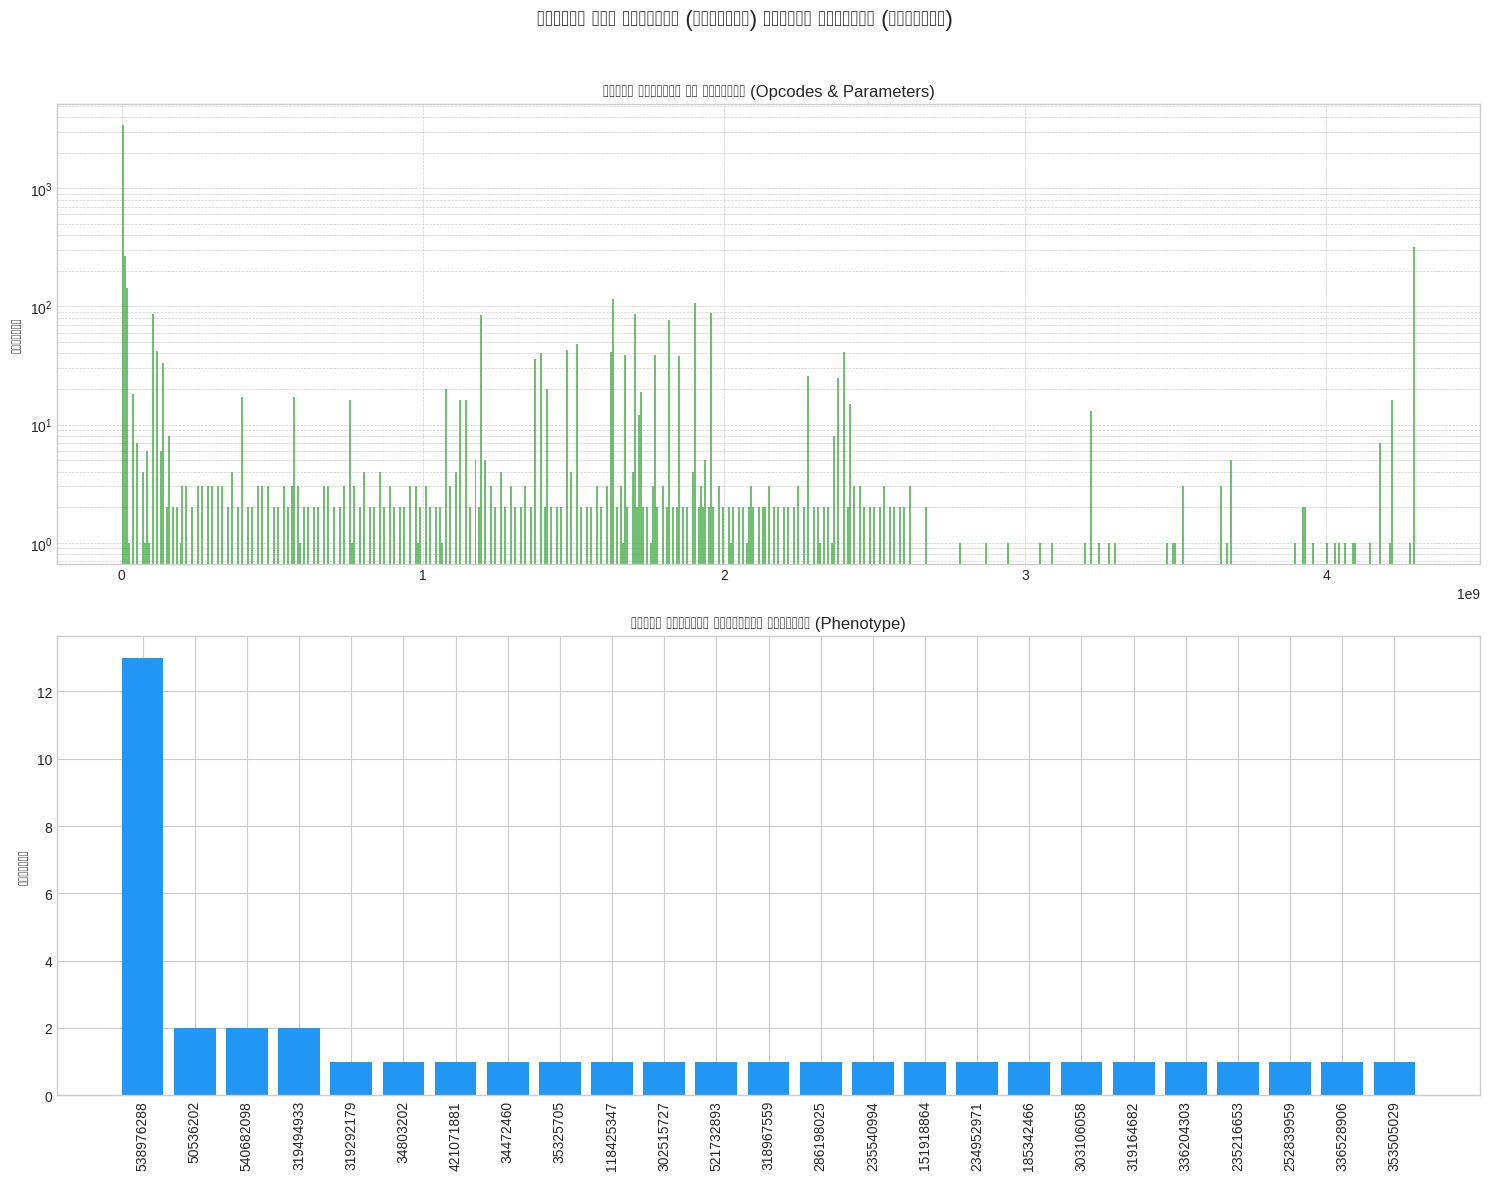

In [24]:
import json
import zlib
import base64
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# --- دالة لقراءة "الجينوم" (info.json) ---
def get_genome_data(info_path):
    with open(info_path, 'r') as f:
        content = f.read()
    info_data = json.loads(content)
    pubs = info_data.get('params', {}).get('pubs', [])
    compressed_value = pubs[0][0].get('__value__', '')
    decoded = base64.b64decode(compressed_value)
    decompressed = zlib.decompress(decoded)
    genome = np.frombuffer(decompressed, dtype=np.uint32)
    return genome

# --- دالة لقراءة "النمط الظاهري" (result.json) ---
def get_phenotype_data(result_path):
    with open(result_path, 'r') as f:
        content = f.read()
    matches = re.findall(r'"__value__":\s*"([^"]+)"', content)
    encoded_str = next((m for m in matches if m.startswith('eJyd')), None)
    decoded = base64.b64decode(encoded_str)
    decompressed = zlib.decompress(decoded)
    # الطريقة الصحيحة التي اكتشفناها: قائمة مسطحة من النتائج
    results_raw = np.frombuffer(decompressed, dtype=np.uint32)
    counts = Counter(results_raw)
    df = pd.DataFrame(counts.items(), columns=['State', 'Frequency'])
    df = df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
    return df

# --- الكود الرئيسي للمقارنة والتحليل ---
def compare_genome_phenotype(info_path, result_path):
    print("🔬 جاري مقارنة الجينوم (الدائرة) بالنمط الظاهري (النتائج)...\n")
    
    # 1. تحليل الجينوم
    genome = get_genome_data(info_path)
    print("--- 🧬 تحليل الجينوم (من info.json) ---")
    print(f"طول الجينوم (عدد التعليمات/البيانات): {len(genome)}")
    unique_genes = np.unique(genome)
    print(f"عدد الجينات الفريدة (Unique Opcodes?): {len(unique_genes)}")
    print(f"أكثر 10 جينات تكرارًا:\n{pd.Series(genome).value_counts().head(10)}\n")

    # 2. تحليل النمط الظاهري
    phenotype_df = get_phenotype_data(result_path)
    print("--- 🔬 تحليل النمط الظاهري (من result.json) ---")
    total_shots = phenotype_df['Frequency'].sum()
    print(f"إجمالي المحاولات (Shots): {total_shots}")
    print(f"عدد الحالات الفريدة الناتجة: {len(phenotype_df)}")
    print("أكثر 10 حالات ظهورًا:")
    print(phenotype_df.head(10))
    
    # 3. الرسم البياني المزدوج
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=False)
    fig.suptitle("مقارنة بين الجينوم (الدائرة) والنمط الظاهري (النتائج)", fontsize=16)

    # رسم هيستوغرام للجينوم
    ax1.hist(genome, bins=len(unique_genes), color='#4CAF50', alpha=0.8)
    ax1.set_title("توزيع الجينات في الدائرة (Opcodes & Parameters)")
    ax1.set_ylabel("التكرار")
    ax1.set_yscale('log') # استخدام مقياس لوغاريتمي لرؤية الجينات النادرة
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

    # رسم النتائج الكمومية
    plot_df = phenotype_df.head(25) # عرض أفضل 25 نتيجة
    # تحويل الأرقام الكبيرة إلى نصوص لتجنب مشاكل الرسم
    plot_df['State_str'] = plot_df['State'].astype(str)
    ax2.bar(plot_df['State_str'], plot_df['Frequency'], color='#2196F3')
    ax2.set_title("توزيع الحالات النهائية الناتجة (Phenotype)")
    ax2.set_ylabel("التكرار")
    ax2.tick_params(axis='x', rotation=90)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# --- التنفيذ ---
info_path = '/kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-info.json'
result_path = '/kaggle/input/datasets/hamidchaouchi/job-d7nse0c97osc73dsffa0/job-d7nse0c97osc73dsffa0-result.json'

compare_genome_phenotype(info_path, result_path)